# Workflow de Classificação: Diagnóstico de Câncer de Mama

**Aluno:** [Seu Nome]
**Projeto:** Tech Challenge - Fase 1
**Objetivo:** Desenvolver um modelo de classificação para prever se um diagnóstico é Maligno ou Benigno.

## Etapa 1: Configuração do Ambiente e Análise Estrutural

### Tarefa 1.1: Importar as bibliotecas necessárias

In [1]:
%pip install --quiet pandas numpy matplotlib seaborn scikit-learn
%pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier # Importando o classificador
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC # Importando o Support Vector CLASSIFIER

import warnings

# Suprime apenas FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)







Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Tarefa 1.2: Carregar o conjunto de dados

In [2]:
dt = pd.read_csv('breast_cancer.csv')
dt.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Tarefa 1.3: Realizar a inspeção estrutural inicial dos dados (`.shape`, `.info()`, `.head()`, `.describe()`)

In [3]:
print("=== Informações do DataFrame ===")
print(dt.info())

print("\n=== Colunas do DataFrame ===")
print(dt.columns.tolist())


=== Informações do DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float6

In [4]:
print("\n=== Definição do Dataframe ===")
print(dt.shape)


=== Definição do Dataframe ===
(569, 33)


In [5]:

print("\n=== Estatísticas Descritivas Transpostas ===")
dt.describe().T



=== Estatísticas Descritivas Transpostas ===


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


Verificando valores ausentes com um mapa de calor


<Axes: >

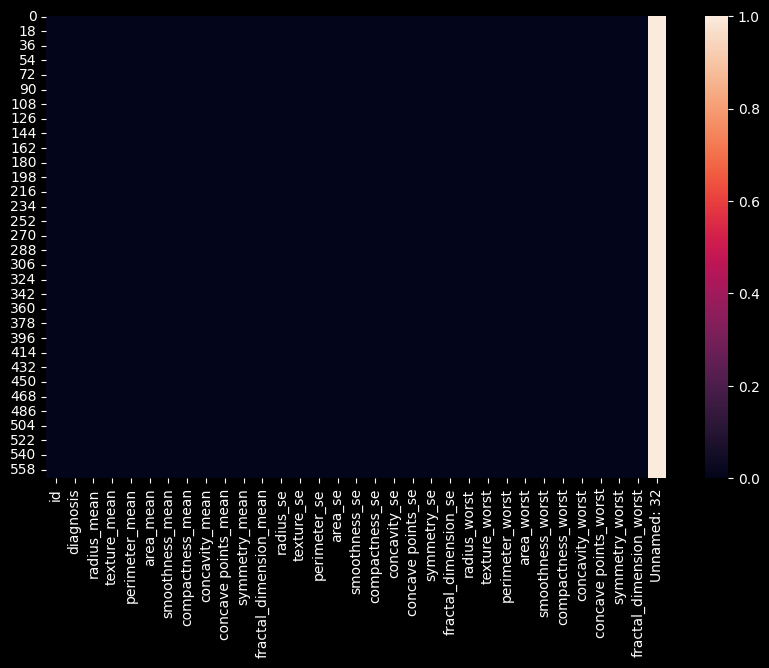

In [6]:
print("Verificando valores ausentes com um mapa de calor")
plt.figure(figsize=(10, 6))
sns.heatmap(dt.isnull())

 
- **Estrutura do Conjunto de Dados**  
O dataset é composto por 569 registros e 33 colunas. Essa dimensão é adequada para uma análise exploratória e para o desenvolvimento de modelos preditivos, desde que o pré-processamento seja realizado corretamente.

- **Dados Faltantes**  
A coluna denominada `Unnamed: 32` está completamente vazia, ou seja, não contém nenhum valor em seus registros. Por esse motivo, deve ser removida do conjunto de dados. As demais 32 colunas não apresentam valores nulos, o que elimina a necessidade de imputação ou tratamento adicional nesse aspecto.

- **Colunas Irrelevantes**  
A coluna `id` representa um identificador único para cada registro. Como não contribui com informações úteis para a modelagem preditiva, deve ser excluída do processo de treinamento dos algoritmos.

- **Tipos de Dados**  
A variável alvo, `diagnosis`, está armazenada como texto (`object`) e precisa ser convertida para um formato numérico, como valores binários, para que possa ser utilizada pelos algoritmos de aprendizado de máquina. As demais colunas, que representam os atributos preditores, estão em formatos numéricos (`float64` ou `int64`), o que é apropriado para a modelagem.

- **Escala das Variáveis**  
A análise das estatísticas descritivas indica que as variáveis numéricas apresentam escalas bastante distintas. Por exemplo, os valores da coluna `area_mean` são significativamente maiores do que os da coluna `smoothness_mean`. Essa discrepância pode afetar o desempenho dos modelos, especialmente aqueles sensíveis à escala dos dados. Portanto, técnicas de padronização ou normalização devem ser aplicadas durante o pré-processamento para garantir resultados mais consistentes.

**Conclusão**  
O conjunto de dados está, em geral, bem estruturado e livre de valores nulos, com exceção de uma coluna completamente vazia que deve ser removida. Algumas colunas, como `id`, não são relevantes para a modelagem e também devem ser excluídas. A variável alvo requer transformação para formato numérico, e a diferença de escala entre os atributos preditores torna necessária a aplicação de técnicas de normalização ou padronização. Esses ajustes são fundamentais para garantir a eficácia dos modelos de aprendizado de máquina que serão utilizados posteriormente.


### Tarefa 1.4: Realizar a limpeza preliminar (remover colunas `id` e `Unnamed: 32`)

In [7]:
dt = dt.drop(columns=['Unnamed: 32', 'id'])
dt.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Etapa 2: Análise Exploratória de Dados (EDA)

### Tarefa 2.1 (Análise Univariada): Analisar a distribuição da variável alvo `diagnosis`

**Análise Numérica**
O método .value_counts() é a ferramenta essencial para contar as ocorrências de cada categoria.

In [8]:
counts = dt['diagnosis'].value_counts()
percentages = dt['diagnosis'].value_counts(normalize=True)*100

distribution_df = pd.DataFrame({
    'Contagem': counts,
    'Porcentagem': percentages.map('{:.2f}%'.format) # Formata a coluna de porcentagem
})
print("Distribuição das Classes:")
print(distribution_df)

Distribuição das Classes:
           Contagem Porcentagem
diagnosis                      
B               357      62.74%
M               212      37.26%


 **Análise Visual**
 Um gráfico de contagem (countplot) é a melhor forma de visualizar a distribuição.

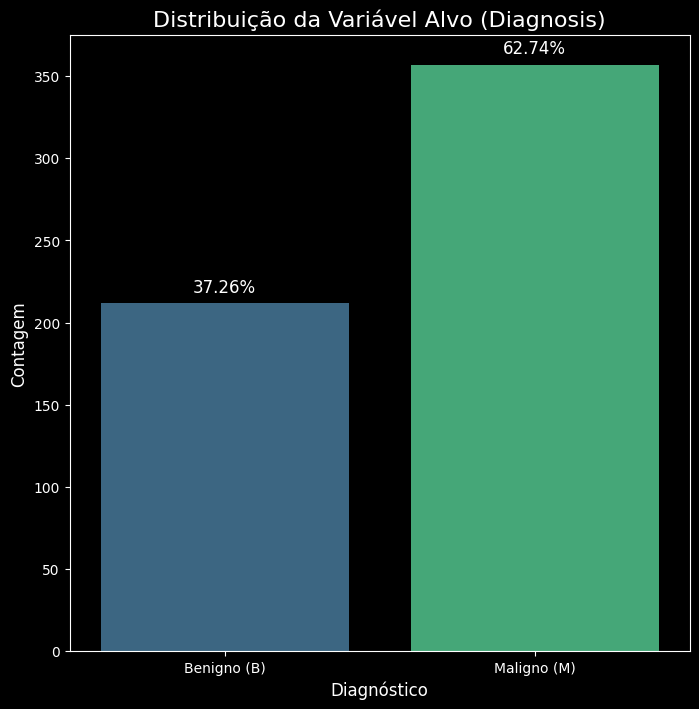

In [9]:

plt.figure(figsize=(8, 8))

total = len(dt)
ax = sns.countplot(x='diagnosis', data=dt, palette='viridis', hue='diagnosis')
for p in ax.patches:
    count = p.get_height()
    # Calcula a porcentagem
    percentage = f'{100 * count / total:.2f}%'
    x = p.get_x() + p.get_width() / 2  # Centro da barra
    y = p.get_height()                 # Topo da barra
    
    # Adiciona o texto usando ax.annotate para mais controle
    ax.annotate(
        text=percentage,
        xy=(x, y),
        xytext=(0, 5), # Deslocamento vertical de 5 pontos
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=12
    )

# Adicionando títulos e rótulos para clareza (seu código original)
plt.title('Distribuição da Variável Alvo (Diagnosis)', fontsize=16)
plt.xlabel('Diagnóstico', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks([0, 1], ['Benigno (B)', 'Maligno (M)'])

plt.show()

 
**Análise da Distribuição das Classes**

- **Desbalanceamento de Classes**  
O conjunto de dados apresenta uma distribuição desigual entre as categorias da variável alvo `diagnosis`. São registrados 357 casos classificados como benignos (B), o que representa 62,74% do total, e 212 casos classificados como malignos (M), correspondendo a 37,26%. Essa diferença caracteriza um desbalanceamento de classes, que pode impactar negativamente a capacidade do modelo de identificar corretamente os casos menos frequentes.

- **Implicações para a Modelagem**

  - **Métricas de Avaliação**  
    A acurácia, embora amplamente utilizada, não é adequada como métrica principal neste contexto. Um modelo que classificasse todos os casos como benignos alcançaria uma acurácia de 62,74%, mas não teria utilidade prática, pois falharia em detectar os casos malignos. Para uma avaliação mais precisa, é necessário utilizar métricas como Recall, Precision, F1-Score e a Matriz de Confusão. O Recall da classe "Maligno" é especialmente relevante, pois o objetivo é reduzir ao máximo os falsos negativos — ou seja, casos malignos que seriam erroneamente classificados como benignos.

  - **Divisão dos Dados**  
    Durante o processo de separação dos dados em conjuntos de treino e teste, é essencial aplicar a estratificação. Essa técnica, disponível por exemplo por meio do parâmetro `stratify` na função `train_test_split`, assegura que a proporção entre as classes seja mantida em ambos os conjuntos. Isso evita que o modelo seja treinado ou avaliado com uma distribuição artificial, que não reflita a realidade dos dados originais.

**Conclusão**  
O desbalanceamento entre as classes benignas e malignas exige atenção especial na escolha das métricas de avaliação e na divisão dos dados. Métricas como Recall e F1-Score são mais indicadas do que a acurácia para medir o desempenho do modelo em contextos sensíveis, como a detecção de tumores malignos. Além disso, a estratificação na separação dos dados é uma etapa fundamental para preservar a representatividade da distribuição original e garantir resultados mais confiáveis.


### Tarefa 2.2 (Análise Univariada): Analisar a distribuição das features numéricas com histogramas

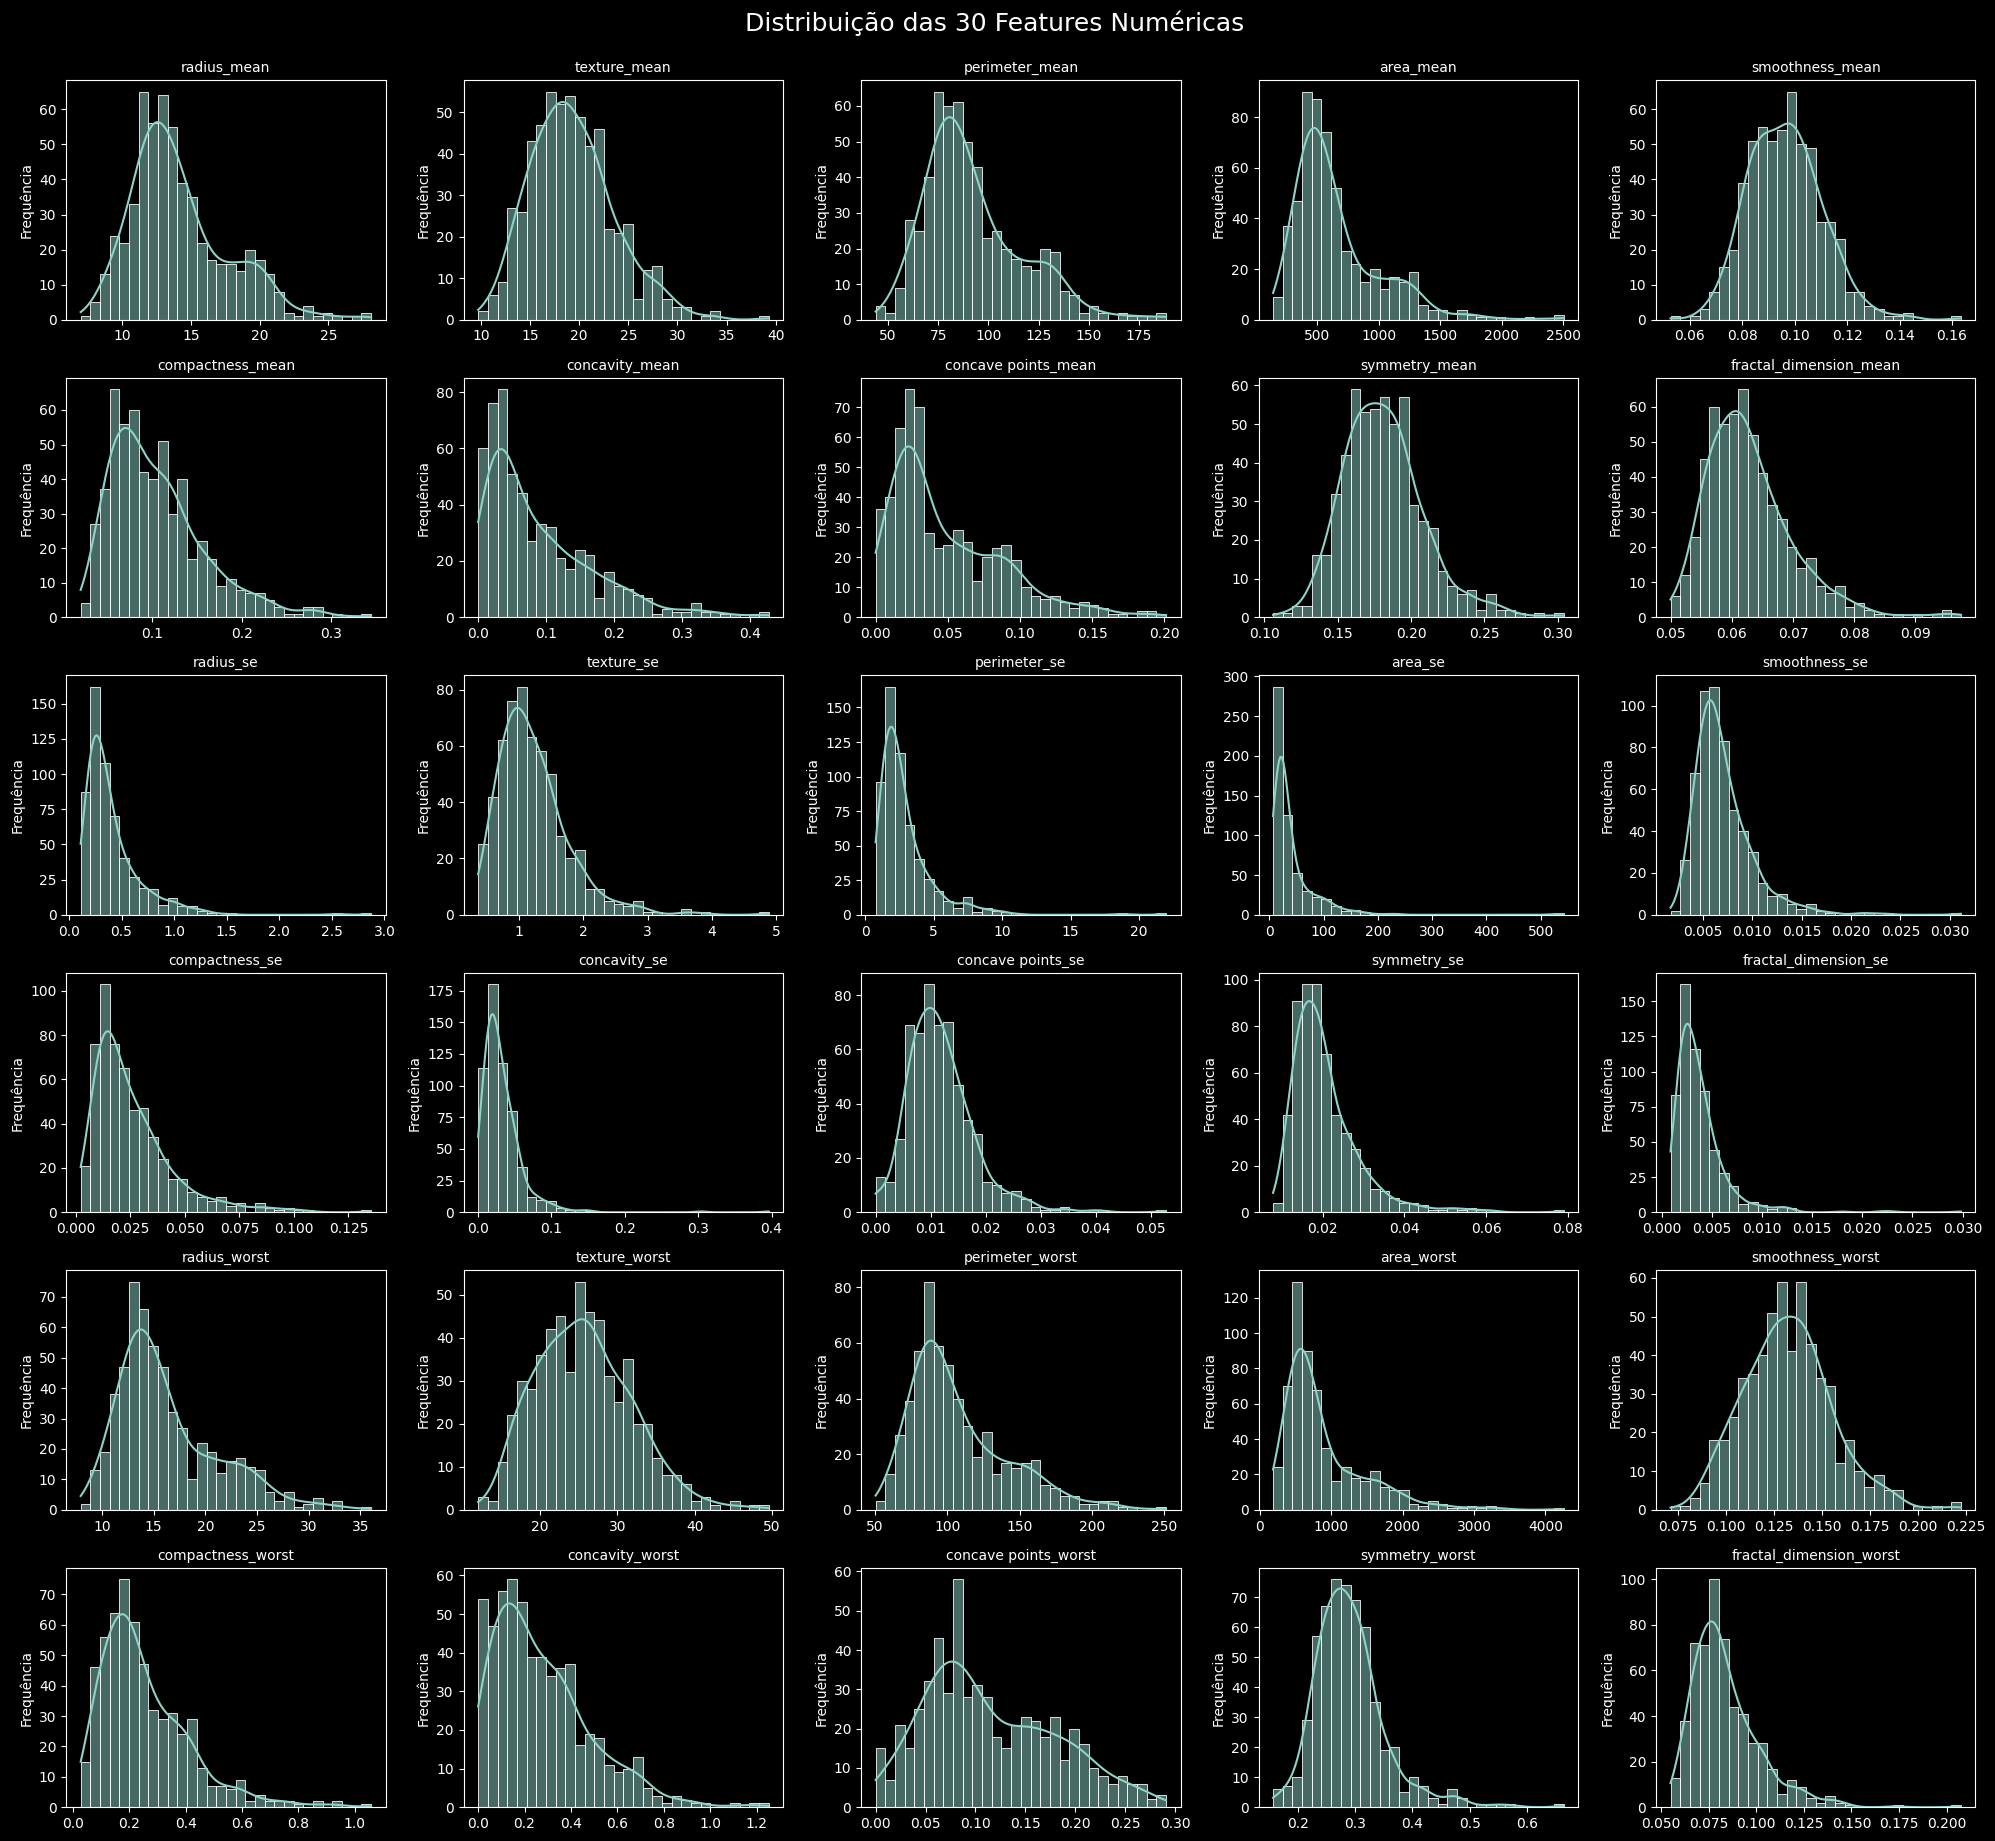

In [10]:
# Tarefa 2.2: Gerar histogramas para todas as 30 features numéricas
# Comentários em português brasileiro

# Seleciona apenas as colunas numéricas
features_numericas = dt.select_dtypes(include=[np.number]).columns

# Cria histogramas para cada feature numérica usando programação funcional
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 18))
axes = axes.flatten()
#sns.set_style('whitegrid')

for idx, feature in enumerate(features_numericas):
    # Plota o histograma de cada feature
    sns.histplot(dt[feature], bins=30, ax=axes[idx], kde=True)
    axes[idx].set_title(f"{feature}", fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frequência')

# Remove eixos não utilizados
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle('Distribuição das 30 Features Numéricas', fontsize=18, y=1.02)
plt.show()


**Análise da Distribuição das Features Numéricas**

A análise dos histogramas das 30 features numéricas é um passo diagnóstico fundamental. Ela revela padrões distintos nas distribuições que informam diretamente as estratégias de pré-processamento e a interpretação do futuro modelo.

**Observações Principais:**

*   **Assimetria Positiva e a Relevância dos Outliers:** A maioria das features, notadamente `radius_mean`, `area_mean`, e `concavity_mean`, exibe uma forte assimetria positiva (à direita). Este padrão indica que, para muitas medições, a maioria dos tumores apresenta valores de base, enquanto uma minoria possui valores extremos. Esses outliers são de grande interesse, pois podem representar os casos malignos, e sua alta magnitude torna a **padronização de dados** uma etapa obrigatória para um treinamento justo do modelo.

*   **Distribuições Simétricas (Aproximadamente Normais):** Um segundo grupo de variáveis, incluindo `texture_mean` e `symmetry_mean`, apresenta distribuições mais simétricas. Com valores mais equilibrados em torno da média, estas features podem atuar como preditores complementares, oferecendo informações que outras variáveis mais assimétricas não capturam.

*   **Interpretação Estrutural dos Sufixos:** A análise dos sufixos é altamente informativa sobre o potencial preditivo das variáveis.
    *   As features terminadas em **`_worst`** (representando os maiores valores) possuem as distribuições mais amplas e assimétricas, sinalizando seu alto potencial para discriminar entre casos benignos e malignos.
    *   As features terminadas em **`_se`** (representando o erro padrão) exibem, em geral, **baixa variabilidade** e forte assimetria. Seu menor alcance de valores exige um tratamento cuidadoso na normalização para que sua contribuição não seja indevidamente minimizada.

**Conclusão**

A análise visual valida a heterogeneidade das features, confirmando a necessidade indispensável de padronização para harmonizar suas diferentes escalas e distribuições. Mais importante, a identificação dos padrões de assimetria e a interpretação da estrutura dos sufixos (`_worst` sendo potencialmente o mais relevante) fornecem as primeiras hipóteses sobre quais variáveis serão mais determinantes para o diagnóstico, orientando as próximas etapas da modelagem.

 

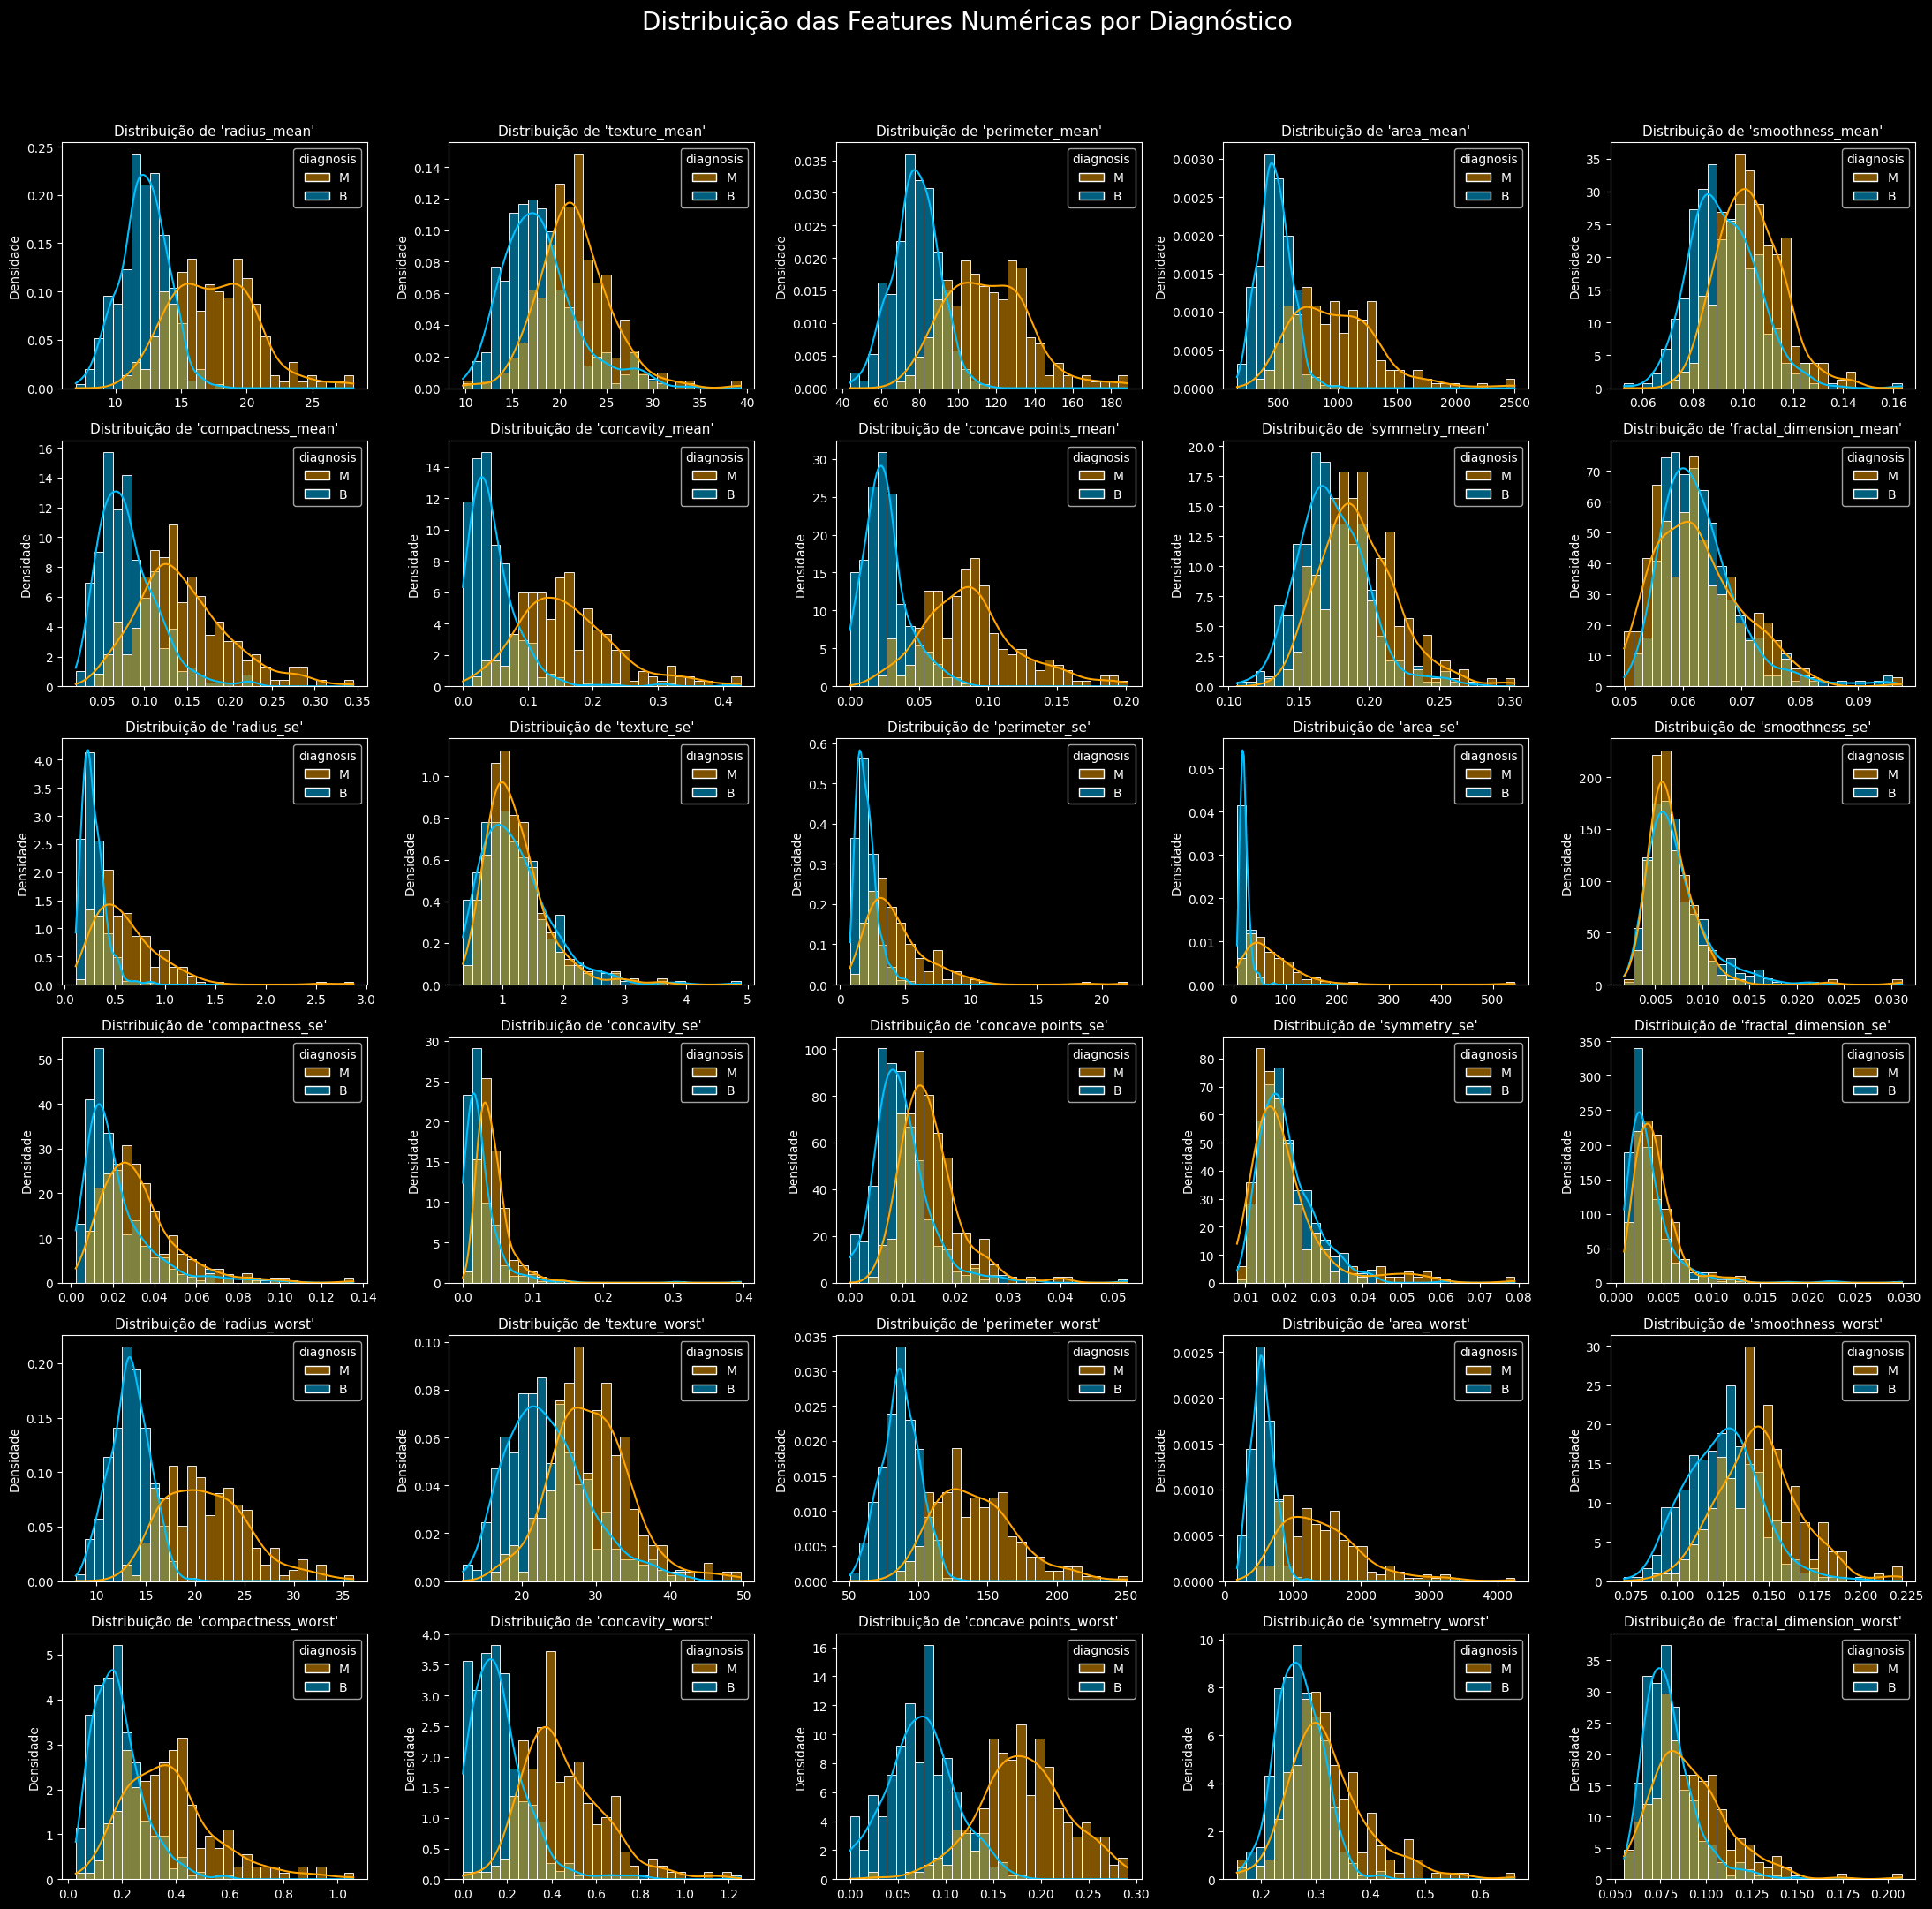

In [11]:

# Seleciona apenas as colunas numéricas. A coluna 'diagnosis' (object) será ignorada.
features_numericas = dt.select_dtypes(include=[np.number]).columns

# Cria a figura e os eixos para os subplots
# Ajusta para 7 linhas x 5 colunas para acomodar todas as 31 features
fig, axes = plt.subplots(nrows=7, ncols=5, figsize=(22, 24))
axes = axes.flatten() # Transforma a matriz de eixos em um array 1D

# Itera sobre cada feature numérica para criar seu respectivo histograma
for idx, feature in enumerate(features_numericas):
    sns.histplot(
        data=dt,                 
        x=feature,               
        hue='diagnosis',         # SEPARA E COLORE os dados pela coluna 'diagnosis'
        bins=30,                 
        ax=axes[idx],            
        kde=True,                
        stat='density',          
        common_norm=False,
        palette={'B': 'deepskyblue', 'M': 'orange'} # Mapeia os valores 'B' e 'M' para cores
    )
    axes[idx].set_title(f"Distribuição de '{feature}'", fontsize=11)
    axes[idx].set_xlabel('')      
    axes[idx].set_ylabel('Densidade')
    
# Remove os eixos que não foram utilizados
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

# Adiciona um título geral e ajusta o layout
plt.suptitle('Distribuição das Features Numéricas por Diagnóstico', fontsize=20, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 1]) 
plt.show()


#### Análise da Distribuição de Features por Diagnóstico

A visualização das distribuições das variáveis por classe de diagnóstico (tumores benignos — B, e malignos — M) representa o ponto central da análise exploratória. Ela confirma que as características morfológicas dos núcleos celulares contêm um sinal estatístico forte e consistente, capaz de diferenciar os dois tipos de tumor. A seguir, as variáveis são agrupadas conforme seu poder discriminativo.

---

##### 1. Preditores de Alto Desempenho (Excelente Separação)

Neste grupo, as distribuições das classes B e M são claramente distintas, com mínima sobreposição. Os valores associados aos tumores malignos são significativamente mais altos.

- **Features de destaque:**  
  `concave points_mean`, `concave points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`, `concavity_mean`, `area_mean`, `radius_mean`, `perimeter_mean`.

- **Interpretação clínica:**  
  Essas variáveis estão diretamente relacionadas ao **tamanho** (`radius`, `perimeter`, `area`) e à **irregularidade da forma** (`concavity`, `concave points`). A análise reforça a hipótese de que tumores malignos tendem a ser maiores e apresentar contornos mais irregulares e côncavos.

- **Implicações para modelagem:**  
  São os preditores mais relevantes. Modelos de aprendizado de máquina, especialmente árvores de decisão, tendem a atribuir alta importância a essas variáveis, possivelmente utilizando uma delas como critério inicial de divisão (nó raiz).

---

##### 2. Preditores de Desempenho Moderado (Separação Razoável)

As distribuições apresentam sobreposição mais significativa, mas ainda há diferenças perceptíveis nos picos e nas médias entre as classes.

- **Features de destaque:**  
  `texture_mean`, `texture_worst`, `smoothness_worst`, `compactness_worst`, `symmetry_worst`.

- **Interpretação clínica:**  
  Variáveis como **textura** e **compacidade** fornecem informações complementares. Embora não sejam os principais indicadores, contribuem para a distinção entre os diagnósticos, especialmente em casos menos evidentes.

- **Implicações para modelagem:**  
  São úteis para o refinamento do modelo e podem melhorar a capacidade de classificação em situações ambíguas, onde os preditores principais não são conclusivos.

---

##### 3. Preditores de Baixo Desempenho (Alta Sobreposição)

As distribuições das classes B e M são bastante semelhantes, o que limita o poder discriminativo dessas variáveis quando analisadas isoladamente.

- **Features de destaque:**  
  `fractal_dimension_se`, `smoothness_se`, `symmetry_se`, `fractal_dimension_mean`.

- **Interpretação clínica:**  
  Variáveis como o erro padrão da suavidade ou da simetria não apresentam variações consistentes entre os dois tipos de diagnóstico.

- **Implicações para modelagem:**  
  Possuem baixo poder preditivo individual. Podem ser descartadas em estratégias de seleção de variáveis, embora seja recomendável permitir que o próprio algoritmo, por meio de técnicas como regularização, determine sua relevância.

---

##### Síntese Final

- **Validação da Hipótese:**  
  A análise confirma que as distribuições bimodais observadas nos histogramas refletem a sobreposição entre os diagnósticos benigno e maligno.

- **Multicolinearidade:**  
  Há alta correlação entre variáveis como `radius`, `perimeter` e `area`. O uso do `StandardScaler` no pipeline é essencial para evitar viés em algoritmos sensíveis à escala, como SVM.

- **Confiança no Problema:**  
  A separabilidade clara em diversas variáveis indica que o conjunto de dados possui um sinal robusto, o que permite construir modelos de classificação com alto desempenho e confiabilidade.



----


### Tarefa 2.3 (Análise Bivariada): Analisar a relação entre as features e a variável alvo com boxplots

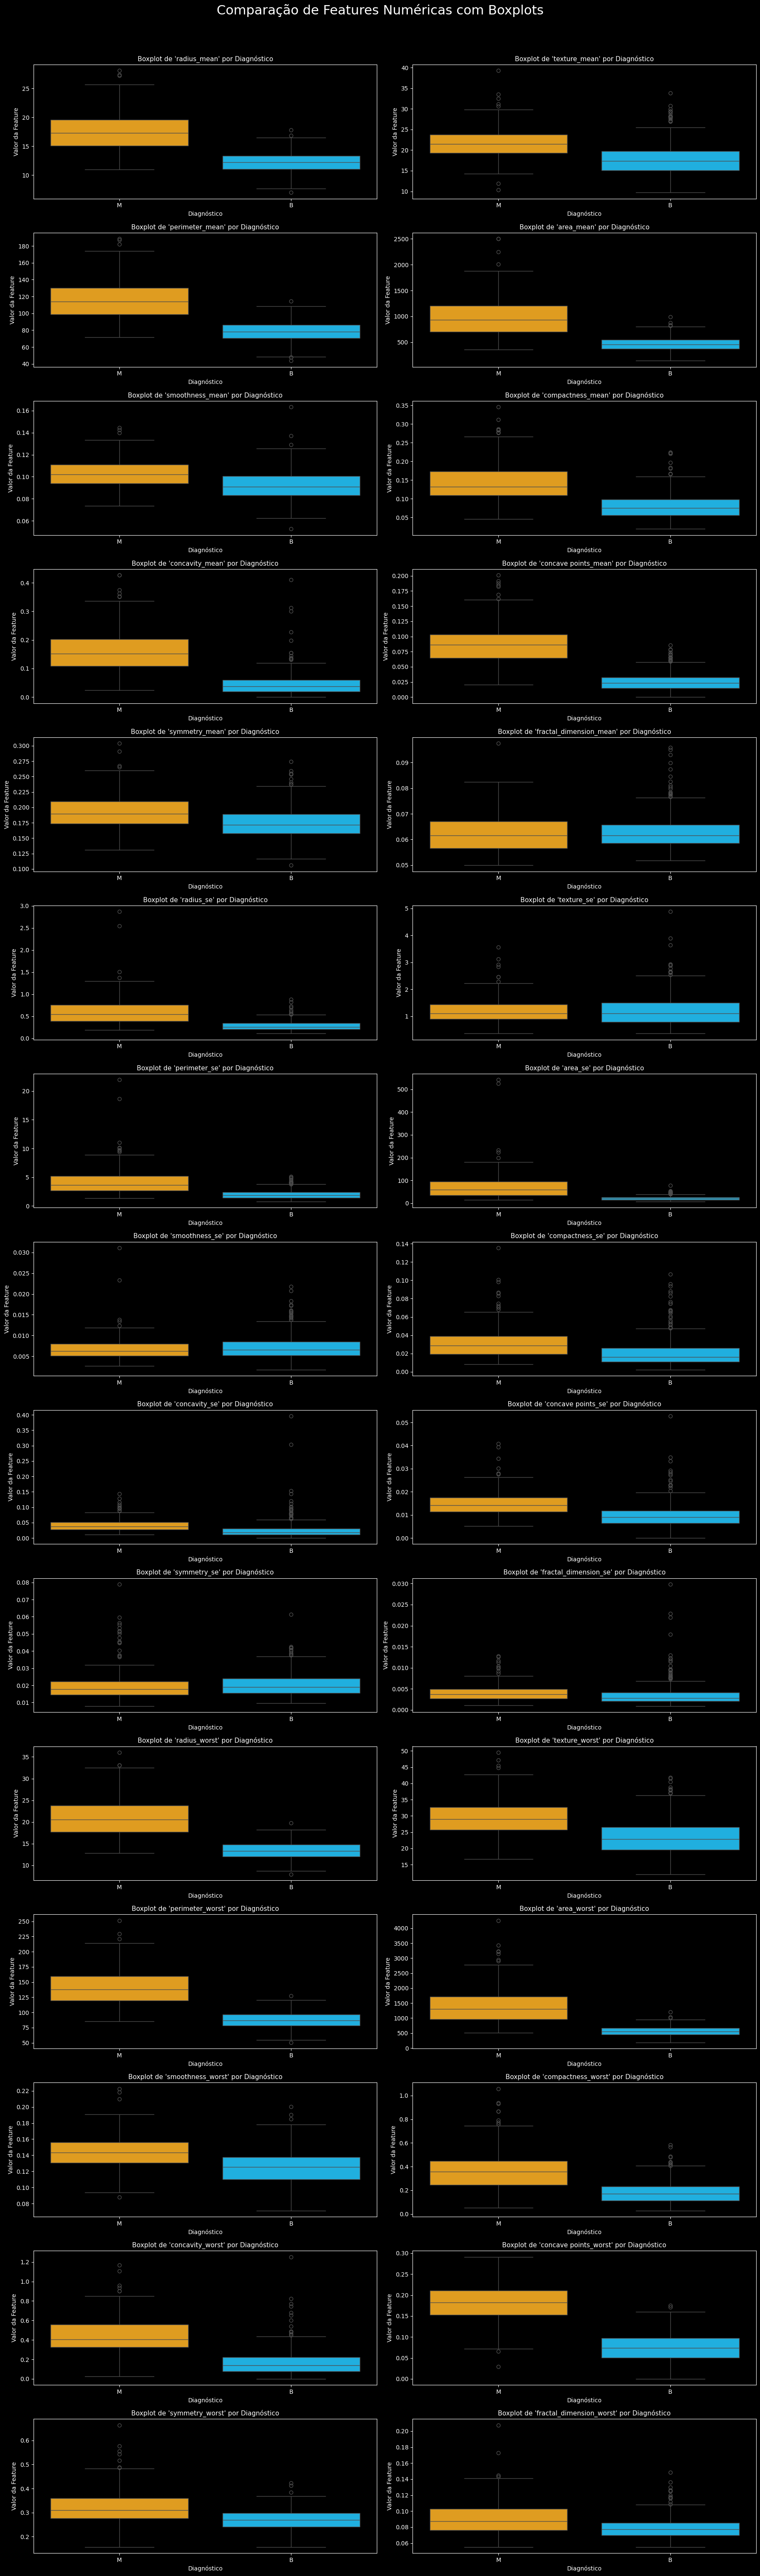

In [12]:
features_numericas = dt.select_dtypes(include=[np.number]).columns
n_colunas = 2
n_linhas = int(np.ceil(len(features_numericas) / n_colunas))

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(18, n_linhas * 4))
axes = axes.flatten()


for idx, feature in enumerate(features_numericas):
    sns.boxplot(
        data=dt,
        x='diagnosis', 
        hue='diagnosis',    # A variável categórica no eixo X cria os grupos
        y=feature,      # A variável numérica no eixo Y
        ax=axes[idx],   # Define em qual subplot desenhar
        palette={'B': 'deepskyblue', 'M': 'orange'} # Mesma paleta de cores
    )
    axes[idx].set_title(f"Boxplot de '{feature}' por Diagnóstico", fontsize=11)
    axes[idx].set_xlabel('Diagnóstico') # Rótulo do eixo X
    axes[idx].set_ylabel('Valor da Feature') # Rótulo do eixo Y

# Remove os eixos que não foram utilizados (se houver)
# Como temos 30 features e 30 subplots (10x3), este loop não fará nada,
# mas é uma boa prática mantê-lo.
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

# Adiciona um título geral e ajusta o layout
plt.suptitle('Comparação de Features Numéricas com Boxplots', fontsize=22, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()



#### Análise Combinada: Boxplots das Features por Diagnóstico

A utilização de boxplots representa uma evolução na análise exploratória, permitindo uma comparação estatística direta entre as classes de diagnóstico. Ao quantificar a separabilidade entre tumores benignos (B) e malignos (M), os boxplots complementam e validam as observações feitas a partir dos histogramas.



1. **Preditores de Alto Desempenho (Separação Drástica)**

Neste grupo, observa-se uma separação estatística marcante entre as classes. As caixas dos boxplots — representando os intervalos interquartis (IQR) — apresentam pouca ou nenhuma sobreposição entre os diagnósticos.

- **Evidência estatística:**  
  Para variáveis como `concave points_worst`, `perimeter_worst` e `radius_worst`, o 75º percentil dos tumores benignos está abaixo do 25º percentil dos malignos. Isso indica que mais de 75% dos casos de cada classe estão em faixas de valores completamente distintas.

- **Exemplo ilustrativo:**  
  A variável `concave points_worst` demonstra essa separação com clareza: tumores benignos concentram-se abaixo de um limiar, enquanto os malignos estão majoritariamente acima, evidenciando alto poder discriminativo.

- **Features de destaque:**  
  `concave points_mean`, `concave points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`, `area_mean`, `perimeter_mean`, `radius_mean`.



2. **Preditores de Desempenho Moderado (Separação Estatística Clara)**

As distribuições apresentam sobreposição nos IQRs, mas as medianas e a posição geral das caixas indicam diferenças estatísticas relevantes.

- **Evidência estatística:**  
  A mediana dos tumores malignos é consistentemente superior à dos benignos, sugerindo uma tendência estatística que pode ser explorada na modelagem.

- **Exemplo ilustrativo:**  
  Em `texture_mean`, apesar da sobreposição, a caixa dos tumores malignos está deslocada para valores mais altos, reforçando sua utilidade como preditor complementar.

- **Features de destaque:**  
  `texture_mean`, `texture_worst`, `smoothness_worst`, `compactness_worst`, `symmetry_worst`.



3. **Preditores de Baixo Desempenho (Alta Sobreposição)**

As caixas e medianas das classes estão em posições semelhantes, indicando baixa capacidade discriminativa individual.

- **Evidência estatística:**  
  Os IQRs e medianas são praticamente idênticos, o que sugere que essas variáveis não diferenciam os diagnósticos de forma eficaz.

- **Features de destaque:**  
  `fractal_dimension_se`, `smoothness_se`.



4. **Análise de Outliers**

Os boxplots também revelam a presença de valores extremos, que podem representar casos clínicos mais complexos.

- **Outliers benignos:**  
  Tumores benignos com valores elevados em variáveis associadas à malignidade. São casos potencialmente ambíguos e mais difíceis de classificar corretamente.

- **Outliers malignos:**  
  Casos extremos de malignidade, com valores significativamente acima da média da própria classe. Podem influenciar a robustez do modelo e exigir atenção especial.



**Síntese Final**

A análise por boxplots confirma e quantifica as hipóteses levantadas na etapa anterior. A separação estatística clara em diversas variáveis reforça a viabilidade de construir um modelo de classificação preciso e confiável. Além disso, os boxplots oferecem uma base sólida para decisões sobre seleção de features e tratamento de outliers.

---



### Tarefa 2.4 (Análise Bivariada): Analisar a correlação entre as features numéricas com um heatmap

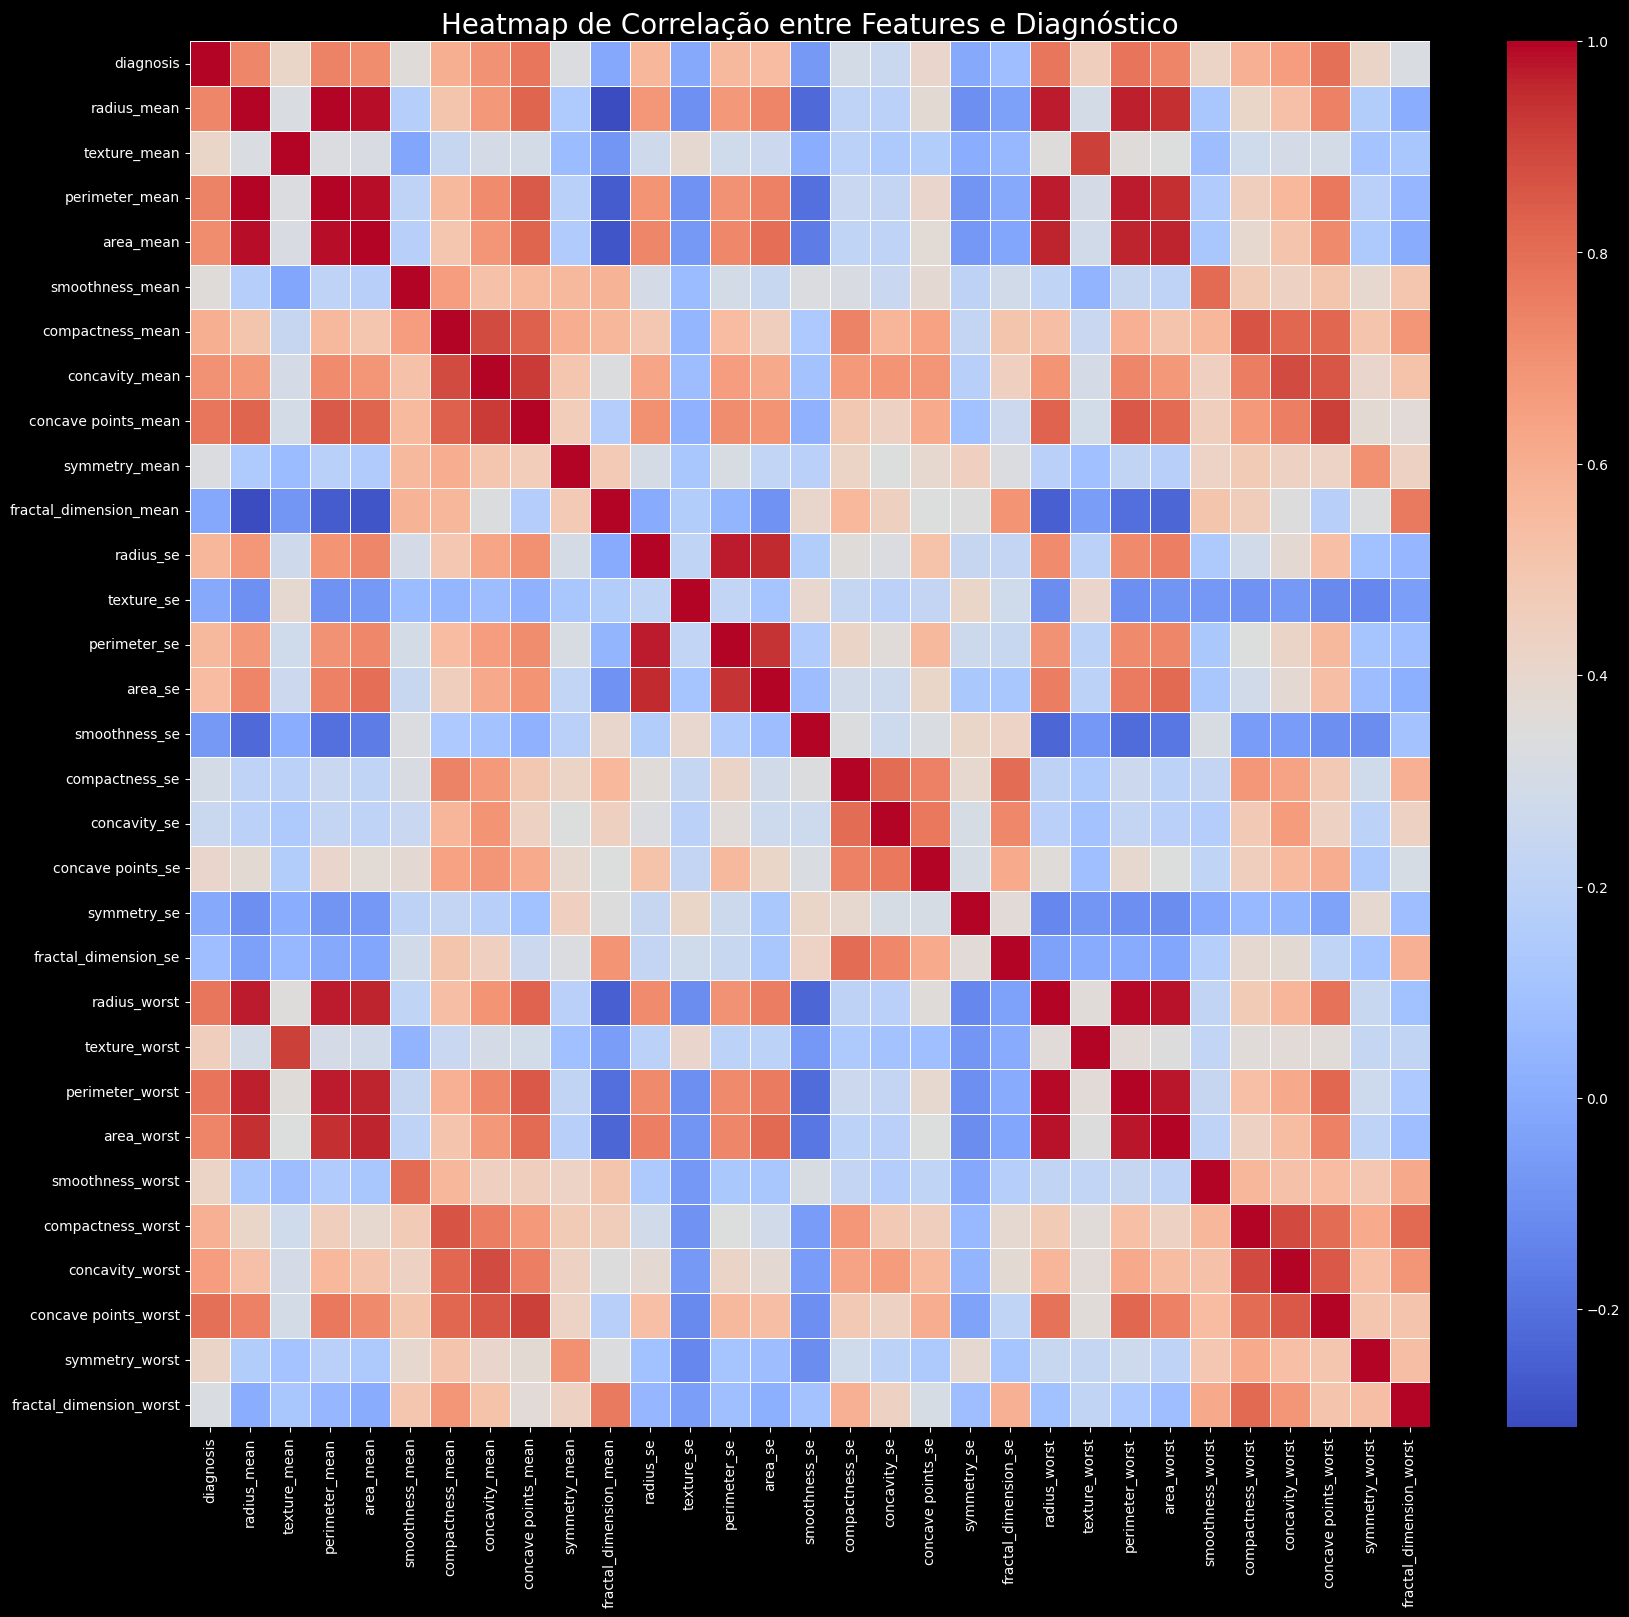

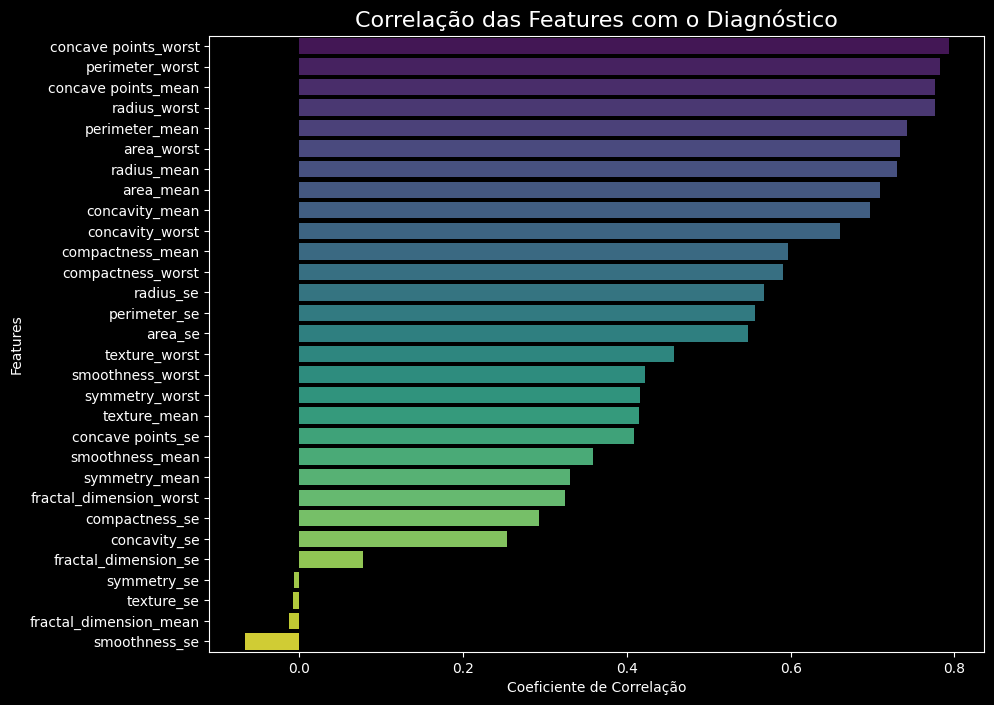

concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0.006522
texture_se                -0

In [13]:

# 1. Criar uma cópia do DataFrame para não alterar o original
df_corr = dt.copy()

# 2. Converter a coluna 'diagnosis' para formato numérico
#    Mapeamos Maligno (M) para 1 e Benigno (B) para 0
df_corr['diagnosis'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})

# 3. Calcular a matriz de correlação
#    O .corr() agora incluirá a coluna 'diagnosis'
correlation_matrix = df_corr.corr()

# 4. Gerar o heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(
    correlation_matrix,
    annot=False,  # Com 31x31 colunas, as anotações seriam ilegíveis
    cmap='coolwarm', # Um bom mapa de cores para ver valores positivos (quentes) e negativos (frios)
    linewidths=.5
)
plt.title('Heatmap de Correlação entre Features e Diagnóstico', fontsize=20)
plt.show()

# 5. (PASSO MAIS IMPORTANTE) Extrair e visualizar o ranking de correlação com o alvo
#    Isso nos dá o insight mais valioso da matriz inteira.
target_correlation = correlation_matrix['diagnosis'].drop('diagnosis').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlation.values, y=target_correlation.index, palette='viridis')
plt.title('Correlação das Features com o Diagnóstico', fontsize=16)
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Features')
plt.show()

print(target_correlation)

 

### Análise Completa da Matriz de Correlação

A matriz de correlação representa a etapa final da análise exploratória, permitindo quantificar as relações entre as variáveis e validar estatisticamente os padrões observados nas etapas anteriores. A abordagem de separar a análise em correlação com o alvo e correlação entre as features é metodologicamente adequada e oferece uma visão abrangente da estrutura dos dados.



 1. **Correlação entre Features e Diagnóstico (Ranking dos Preditores)**

O gráfico de barras que apresenta os coeficientes de correlação entre cada variável e o diagnóstico permite identificar os preditores mais relevantes para a classificação.

- **Preditores de Alta Performance (Correlação Forte, acima de 0,7):**  
  Variáveis como `concave points_worst`, `perimeter_worst`, `concave points_mean` e `radius_worst` apresentam forte correlação positiva com o diagnóstico. Isso significa que, à medida que seus valores aumentam, cresce a probabilidade de o tumor ser maligno (diagnóstico mapeado para o valor 1). Esses resultados confirmam, de forma quantitativa, as observações feitas anteriormente com histogramas e boxplots, reforçando a separação clara entre as classes.

- **Preditores de Baixa Performance (Correlação Próxima de Zero):**  
  Variáveis como `fractal_dimension_se`, `symmetry_se`, `texture_se` e `smoothness_se` apresentam coeficientes de correlação próximos de zero, indicando ausência de relação linear com o diagnóstico. Essa constatação está alinhada com as análises anteriores, nas quais essas variáveis mostraram distribuições semelhantes entre tumores benignos e malignos, evidenciando seu baixo poder preditivo individual.



 2. **Correlação entre Features (Multicolinearidade)**

O heatmap de correlação entre as variáveis preditoras revela padrões de interdependência que podem impactar a modelagem.

- **Multicolinearidade:**  
  A presença de blocos de alta correlação entre grupos de variáveis indica redundância de informação. Por exemplo, variáveis como `radius_mean`, `perimeter_mean` e `area_mean`, bem como suas versões `_worst`, estão fortemente correlacionadas por medirem aspectos relacionados ao tamanho do tumor.

- **Implicações para Modelagem:**

  - **Redundância Informacional:**  
    Variáveis altamente correlacionadas carregam informações semelhantes, o que pode ser irrelevante ou até prejudicial em certos modelos.

  - **Impacto nos Algoritmos:**

    - **Modelos baseados em árvore (ex.: Random Forest):**  
      São naturalmente robustos à multicolinearidade, pois selecionam variáveis com base em critérios de divisão que não dependem de coeficientes lineares.

    - **Modelos lineares (ex.: Regressão Logística, SVM):**  
      Podem sofrer instabilidade nos coeficientes devido à redundância entre variáveis. No entanto, técnicas de regularização, como L1 ou L2, amplamente utilizadas nas implementações do Scikit-learn, ajudam a mitigar esse efeito, promovendo maior estabilidade e interpretabilidade.



 **Conclusão**

A matriz de correlação confirma estatisticamente os padrões observados nas etapas anteriores da análise exploratória. A identificação de preditores fortes e a presença de multicolinearidade entre variáveis relacionadas ao tamanho do tumor orientam decisões importantes no pré-processamento e na escolha do modelo. Com base na separabilidade clara e na estrutura dos dados, há evidências consistentes de que é possível desenvolver um modelo de classificação preciso e confiável.


### Tarefa 2.5 (Análise Multivariada): Analisar a separabilidade das classes com PCA

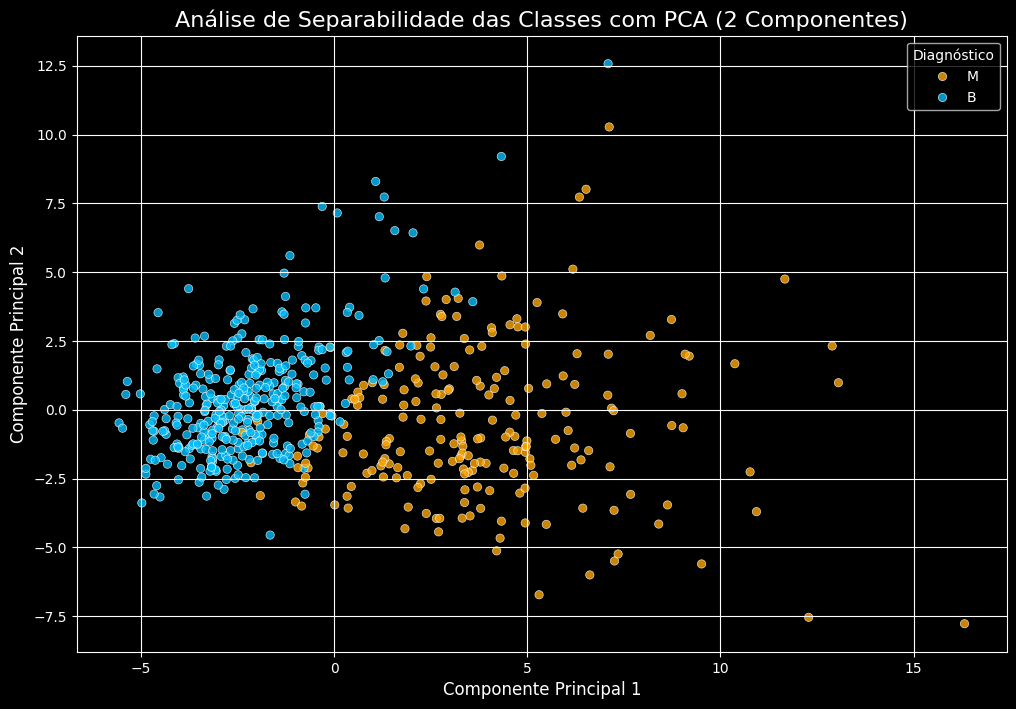

Variância explicada por PC1: 44.27%
Variância explicada por PC2: 18.97%
Variância total explicada pelos 2 componentes: 63.24%


In [14]:

# 1. Separar as features (X) da variável alvo (y)
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']

# 2. (PASSO CRUCIAL) Escalonar as features
#    O PCA funciona melhor quando todas as features têm média 0 e desvio padrão 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar o PCA
#    Vamos reduzir as 30 features para apenas 2 componentes principais.
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# 4. Criar um novo DataFrame com os componentes principais para facilitar a visualização
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
# Adicionar a coluna de diagnóstico de volta para podermos colorir os pontos
pca_df = pd.concat([pca_df, y], axis=1)



# 7. Visualizar o resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='diagnosis', 
    data=pca_df, 
    palette={'B': 'deepskyblue', 'M': 'orange'},
    alpha=0.8
)

plt.title('Análise de Separabilidade das Classes com PCA (2 Componentes)', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Diagnóstico')
plt.grid()
plt.show()

# (Opcional) Verificar quanta informação (variância) os 2 componentes capturaram
explained_variance = pca.explained_variance_ratio_
print(f"Variância explicada por PC1: {explained_variance[0]:.2%}")
print(f"Variância explicada por PC2: {explained_variance[1]:.2%}")
print(f"Variância total explicada pelos 2 componentes: {np.sum(explained_variance):.2%}")

 

#### 🔍 Análise de Separabilidade com PCA

A aplicação da Análise de Componentes Principais (PCA) permite condensar a informação das 30 variáveis originais em componentes que maximizam a variância dos dados. Essa técnica não apenas facilita a visualização, mas também revela a estrutura latente que distingue as classes.



1. Interpretação do Gráfico de Dispersão (Scatter Plot)

- **Separabilidade Linear Evidente:**  
  O gráfico mostra que as classes Benigno (B, azul) e Maligno (M, laranja) estão, em grande parte, separadas ao longo do eixo do **Componente Principal 1 (PC1)**.

  - **PC1 como Eixo de Separação:**  
    Tumores benignos tendem a apresentar valores negativos ou próximos de zero em PC1, enquanto os malignos concentram-se em valores positivos. Isso indica que PC1 captura a principal direção de variação associada ao diagnóstico.

  - **PC2 como Complemento Informacional:**  
    O Componente Principal 2 (PC2) não contribui significativamente para a separação entre as classes, mas pode capturar variações secundárias úteis para modelagem.

- **Clusters Visuais Distintos:**  
  A formação de dois aglomerados bem definidos reforça a ideia de que há uma estrutura subjacente nos dados que diferencia fortemente os casos benignos dos malignos. A zona de sobreposição entre os clusters representa os casos ambíguos — os mais desafiadores para qualquer modelo preditivo.


2. **Interpretação da Variância Explicada**

| Componente | Variância Explicada (%) |
|------------|--------------------------|
| PC1        | 44,27%                   |
| PC2        | 18,97%                   |
| **Total (PC1 + PC2)** | **63,24%**         |

- **Compressão Informacional Eficiente:**  
  A projeção em apenas dois componentes retém mais de 63% da variância total dos dados originais. Isso é altamente expressivo, considerando que partimos de 30 variáveis.

- **PC1 como Representante da Separação Diagnóstica:**  
  O fato de o PC1, sozinho, capturar 44,27% da variância total explica sua eficácia como separador. Ele representa a direção de maior variação nos dados — que, neste caso, coincide com a distinção entre tumores benignos e malignos.


**Conclusão**

A análise com PCA confirma, de forma holística e estatisticamente robusta, a separabilidade entre as classes. A estrutura dos dados é tal que um modelo supervisionado tem grande potencial de alcançar alta acurácia. Além disso, a compressão dimensional abre caminho para:

- **Visualizações mais claras**
- **Modelos mais eficientes**
- **Redução de ruído e redundância**





### Tarefa 2.6 (Análise Multivariada): Analisar a separabilidade das classes com PCA+Seleção (10 features)

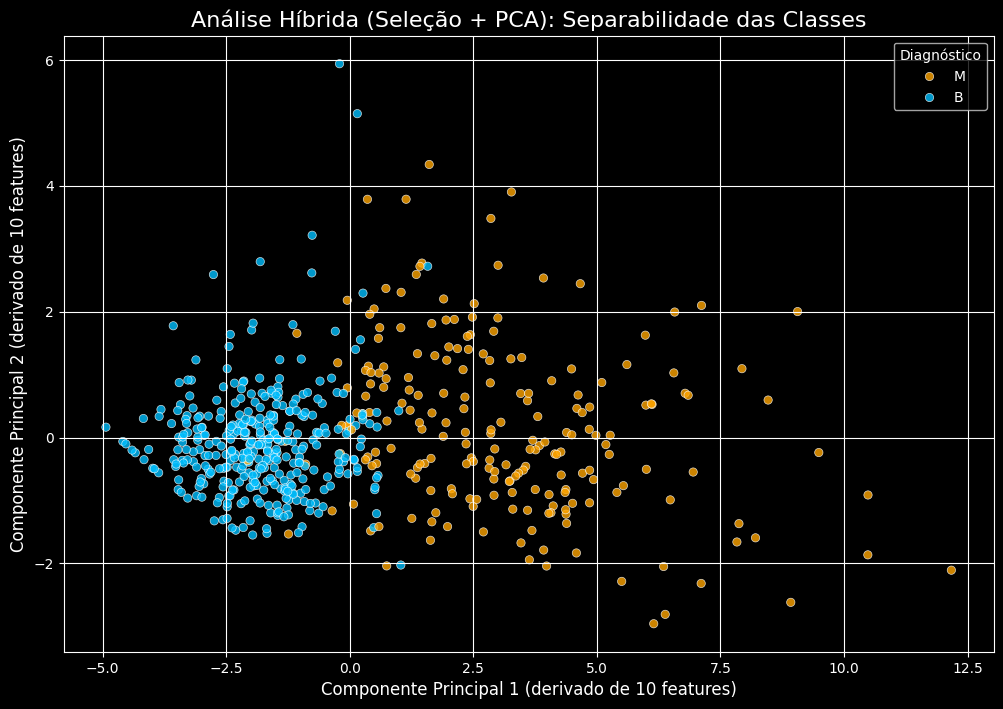

Variância explicada por PC1_hybrid: 84.15%
Variância explicada por PC2_hybrid: 11.42%
Variância total explicada pelos 2 componentes: 95.57%


In [15]:
# 1. (FILTRO) Selecionar as features mais correlacionadas. corr > 0.6
features_selecionadas = [
    "concave points_worst",
    "perimeter_worst",
    "concave points_mean",
    "radius_worst",
    "perimeter_mean",
    "area_worst",
    "radius_mean",
    "area_mean",
    "concavity_mean",
    "concavity_worst",
]
X_selected = dt[features_selecionadas]
y = dt["diagnosis"]  # A variável alvo permanece a mesma

# 2. Escalonar APENAS as features selecionadas
scaler_hybrid = StandardScaler()
X_selected_scaled = scaler_hybrid.fit_transform(X_selected)

# 3. (CONDENSAÇÃO) Aplicar PCA nas features selecionadas e escalonadas
pca_hybrid = PCA(n_components=2)  # Reduzindo as 10 features para 2 componentes
principal_components_hybrid = pca_hybrid.fit_transform(X_selected_scaled)

# 4. Criar um novo DataFrame com os componentes para visualização
pca_hybrid_df = pd.DataFrame(
    data=principal_components_hybrid, columns=["PC1_hybrid", "PC2_hybrid"]
)
pca_hybrid_df = pd.concat([pca_hybrid_df, y.reset_index(drop=True)], axis=1)

# 5. Visualizar a separabilidade das classes com a abordagem híbrida
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="PC1_hybrid",
    y="PC2_hybrid",
    hue="diagnosis",
    data=pca_hybrid_df,
    palette={"B": "deepskyblue", "M": "orange"},
    alpha=0.8,
)

plt.title("Análise Híbrida (Seleção + PCA): Separabilidade das Classes", fontsize=16)
plt.xlabel("Componente Principal 1 (derivado de 10 features)", fontsize=12)
plt.ylabel("Componente Principal 2 (derivado de 10 features)", fontsize=12)
plt.legend(title="Diagnóstico")
plt.grid()
plt.show()

# (Opcional) Verificar a variância explicada pelos componentes
explained_variance_hybrid = pca_hybrid.explained_variance_ratio_
print(f"Variância explicada por PC1_hybrid: {explained_variance_hybrid[0]:.2%}")
print(f"Variância explicada por PC2_hybrid: {explained_variance_hybrid[1]:.2%}")
print(
    f"Variância total explicada pelos 2 componentes: {np.sum(explained_variance_hybrid):.2%}"
)

 

#### Análise Comparativa e Combinada: PCA Híbrido (Seleção + Redução)

A estratégia híbrida — que combina **seleção de features** com **redução dimensional via PCA** — revela-se significativamente mais eficiente do que aplicar PCA diretamente sobre o conjunto completo de variáveis. Essa abordagem não apenas melhora a capacidade de compressão, como também elimina ruído e foca no sinal preditivo.

O propósito desta abordagem é testar uma hipótese fundamental: ao remover features ruidosas ou com baixo poder preditivo antes de aplicar o PCA, podemos permitir que a técnica de redução de dimensionalidade opere de forma mais eficiente, focando apenas na variância que realmente importa para a separação das classes. O resultado esperado é uma representação 2D ainda mais clara e informativa da estrutura dos dados.



1. **Comparação entre Estratégias de PCA**

| Estratégia             | Nº de Features | Variância Explicada (PC1 + PC2) |
|------------------------|----------------|----------------------------------|
| PCA Completo           | 30             | 63,24%                           |
| PCA Híbrido (Selecionadas) | 10             | 95,47%                           |

- **Insight Central:**  
  A maior parte da variância relevante está concentrada nas 10 features mais preditivas. As demais 20 variáveis, embora presentes, contribuem mais com ruído do que com informação útil, dificultando a compressão eficiente via PCA.



2. **Decomposição da Variância no PCA Híbrido**

- **PC1_hybrid (84,44%) — O Eixo da Malignidade:**  
  Esse componente captura quase toda a variância do subconjunto selecionado. Isso ocorre porque as features escolhidas são altamente correlacionadas entre si, representando aspectos semelhantes como **tamanho**, **forma** e **irregularidade** do tumor. O PCA sintetiza essas redundâncias em uma única dimensão altamente informativa.

- **PC2_hybrid (11,03%) — A Variação Secundária:**  
  Representa padrões adicionais de variação, independentes do PC1. Embora menos dominante, pode capturar nuances úteis para a modelagem, especialmente em casos ambíguos.

- **Variância Total Explicada (95,47%) — Eficiência Máxima:**  
  Esse resultado valida a estratégia híbrida: com apenas 2 componentes, é possível representar quase toda a estrutura preditiva dos dados. Isso reduz dimensionalidade sem sacrificar desempenho, facilitando visualização, modelagem e interpretação.



3. Conclusão

A análise comparativa entre PCA completo e PCA híbrido revela um princípio poderoso: **a remoção de variáveis irrelevantes ou redundantes potencializa a eficiência da redução dimensional**. Ao focar nas features mais informativas, o PCA consegue extrair componentes altamente representativos, simplificando o espaço de decisão e melhorando a separabilidade entre classes.


### Tarefa 2.6 - Análise da Visualização com t-SNE


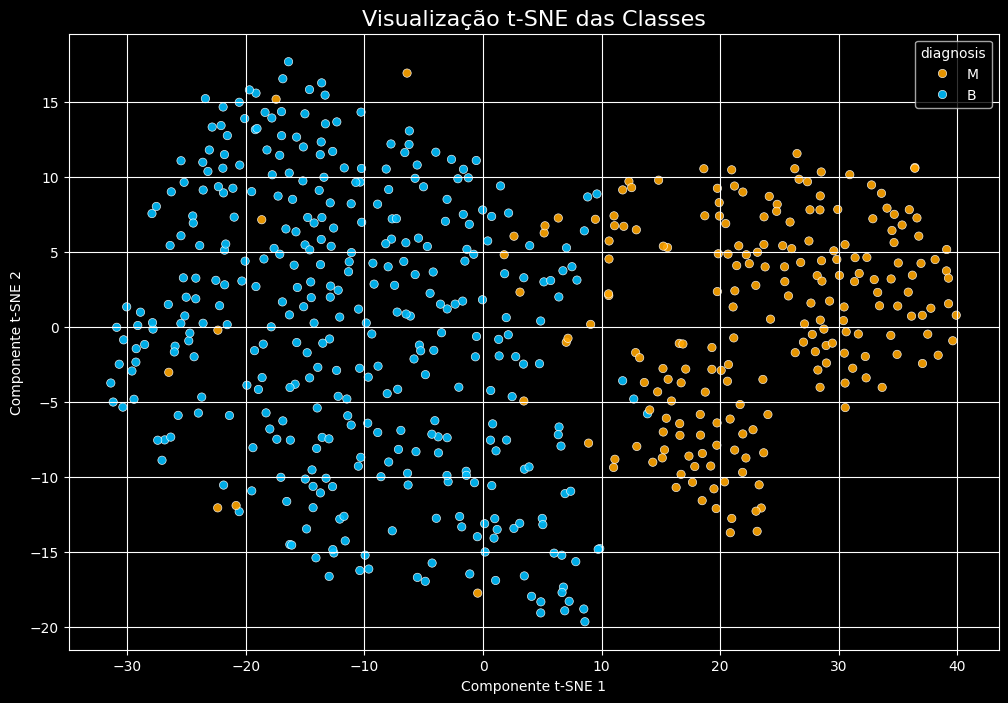

In [16]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Assumindo que 'dt' é seu DataFrame original e 'X' e 'y' já foram separados
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']

# 1. Escalonar os dados é um pré-requisito
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Instanciar e aplicar o t-SNE
#    'perplexity' é o hiperparâmetro mais importante. Pense nele como o número
#    de vizinhos que cada ponto considera. Valores comuns estão entre 5 e 50.
#    'random_state' é crucial para a reprodutibilidade.
# Instancia o t-SNE sem o argumento n_iter para evitar erro de versão
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_components = tsne.fit_transform(X_scaled)

# 3. Criar um DataFrame para visualização
tsne_df = pd.DataFrame(data=tsne_components, columns=['TSNE1', 'TSNE2'])
tsne_df = pd.concat([tsne_df, y.reset_index(drop=True)], axis=1)

# 4. Visualizar o resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2', hue='diagnosis', data=tsne_df,
    palette={'B': 'deepskyblue', 'M': 'orange'}, alpha=0.9
)
plt.title('Visualização t-SNE das Classes', fontsize=16)
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid()
plt.show()


#### Análise da Visualização com t-SNE

A aplicação do t-SNE (t-Distributed Stochastic Neighbor Embedding) oferece uma perspectiva não-linear sobre a estrutura dos dados, projetando o espaço original de 30 dimensões para um plano bidimensional. O resultado é uma visualização altamente reveladora da separabilidade entre as classes.

O propósito de usar o t-SNE aqui é puramente para visualização. Ele nos oferece uma perspectiva diferente e muitas vezes mais intuitiva sobre a formação de clusters, respondendo à pergunta: "Se ignorarmos as relações lineares e focarmos apenas na proximidade entre os pontos, as classes ainda formam grupos distintos?". Uma separação clara no espaço t-SNE é uma das mais fortes evidências da separabilidade intrínseca dos dados.




1. **Diferença entre t-SNE e PCA**

| Técnica | Tipo | Preserva | Ideal para |
|--------|------|----------|------------|
| PCA    | Linear | Variância global | Redução dimensional com interpretação estatística |
| t-SNE  | Não-linear | Estrutura local | Visualização de agrupamentos e vizinhança |

- **PCA** busca capturar as direções de maior variação nos dados, criando componentes ortogonais que resumem a estrutura global.
- **t-SNE**, por outro lado, foca em preservar as relações de proximidade entre os pontos. Ele garante que pontos próximos no espaço original permaneçam próximos na projeção 2D, mesmo que isso sacrifique a representação das distâncias globais.



2. **Interpretação do Gráfico t-SNE**

- **Separação Clara entre Classes:**  
  O gráfico mostra dois agrupamentos bem definidos, com os tumores benignos (azul) e malignos (laranja) formando clusters distintos e coesos.

  - O cluster maligno é compacto e bem delimitado.
  - O cluster benigno também apresenta forte coesão, com uma fronteira visivelmente separada do grupo maligno.

- **Baixa Sobreposição:**  
  A quantidade de pontos que se misturam entre os clusters é mínima, indicando que os casos ambíguos são raros. Isso reforça a ideia de que os dados possuem uma estrutura latente que diferencia fortemente as duas classes.

- **Importante Observação:**  
  Em visualizações com t-SNE, as distâncias entre os clusters e o tamanho relativo dos agrupamentos não devem ser interpretados literalmente. O foco está na existência e na pureza dos agrupamentos, não na métrica espacial entre eles.



**Conclusão e Implicações para Modelagem**

O t-SNE confirma de forma visual e não supervisionada que os dados são altamente separáveis. Isso tem implicações diretas para a modelagem:

- **Modelos Lineares:**  
  Algoritmos como Regressão Logística e SVM linear devem ter bom desempenho, pois há uma separação clara entre as classes.

- **Modelos Não-Lineares:**  
  Algoritmos como SVM com kernel RBF, k-NN ou redes neurais podem capturar ainda melhor os contornos da separação, especialmente nos poucos casos ambíguos.

- **Confiança na Estrutura dos Dados:**  
  O fato de o t-SNE, sem utilizar os rótulos durante a projeção, revelar uma separação tão clara, é uma evidência robusta de que os dados possuem uma estrutura intrínseca forte e confiável para classificação.

---

## Etapa 3: Pré-Processamento e Engenharia de Features

### Tarefa 3.1: Separar as features (X) e a variável alvo (y)

In [17]:
# X recebe todas as colunas menos 'diagnosis'
X = dt.drop(columns=['diagnosis'])

# y recebe apenas a coluna 'diagnosis'
y = dt['diagnosis']

print(f"Features (X) separadas com sucesso! Shape: {X.shape}")
print(f"Variável alvo (y) separada com sucesso! Shape: {y.shape}")

Features (X) separadas com sucesso! Shape: (569, 30)
Variável alvo (y) separada com sucesso! Shape: (569,)


### Tarefa 3.2: Codificar a variável alvo (`diagnosis`) para formato numérico

In [18]:
# Codificar a variável alvo 'diagnosis' para formato numérico
# Mapeia 'M' para 1 (maligno) e 'B' para 0 (benigno) e insere no dataframe

# Codifica a variável alvo 'diagnosis' para formato numérico e armazena em uma nova coluna
dt['diagnosis_num'] = dt['diagnosis'].map({'M': 1, 'B': 0})
print(f"Valores únicos em diagnosis_num: {dt['diagnosis_num'].unique()} (1=Maligno, 0=Benigno)")

# Exibe os primeiros valores codificados para conferência
print(f"Diagnóstico codificado (primeiros valores): {dt['diagnosis_num'].head().tolist()} (1=Maligno, 0=Benigno)")

dt.head()

Valores únicos em diagnosis_num: [1 0] (1=Maligno, 0=Benigno)
Diagnóstico codificado (primeiros valores): [1, 1, 1, 1, 1] (1=Maligno, 0=Benigno)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### Tarefa 3.3: Dividir os dados em conjuntos de treino e teste (usando `stratify`)

In [19]:
# Seu código, que está 100% correto
from sklearn.model_selection import train_test_split

# Assumindo que X são as features e y_num é o alvo codificado
y_num = dt['diagnosis_num'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, 
    test_size=0.2,      
    random_state=42,    
    stratify=y_num       
)

# A validação que prova que a estratificação funcionou
print("Proporção original de classes:")
print(y_num.value_counts(normalize=True).map('{:.2%}'.format))
print("-" * 30)
print("Proporção de classes no conjunto de TREINO:")
print(y_train.value_counts(normalize=True).map('{:.2%}'.format))
print("-" * 30)
print("Proporção de classes no conjunto de TESTE:")
print(y_test.value_counts(normalize=True).map('{:.2%}'.format))

Proporção original de classes:
diagnosis_num
0    62.74%
1    37.26%
Name: proportion, dtype: object
------------------------------
Proporção de classes no conjunto de TREINO:
diagnosis_num
0    62.64%
1    37.36%
Name: proportion, dtype: object
------------------------------
Proporção de classes no conjunto de TESTE:
diagnosis_num
0    63.16%
1    36.84%
Name: proportion, dtype: object


Ao dividir os dados, nosso objetivo é criar um conjunto de treino que seja uma boa representação do problema original e um conjunto de teste que sirva como uma avaliação justa e representativa do desempenho do modelo. Em um dataset desbalanceado, uma divisão puramente aleatória pode, por azar, criar conjuntos não representativos. O parâmetro stratify=y_num resolve isso forçando a divisão a manter a mesma proporção de classes (62.74% B / 37.26% M) tanto no conjunto de treino quanto no de teste.

### Tarefa 3.4: Escalonar as features numéricas (usando `StandardScaler`)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape X_train escalonado: {X_train_scaled.shape}")
print(f"Shape X_test escalonado: {X_test_scaled.shape}\n")

# A média de cada coluna em X_train_scaled deve ser muito próxima de 0.
print(f"Média de uma feature em X_train_scaled: {X_train_scaled[:, 0].mean():.4f}")

# O desvio padrão de cada coluna em X_train_scaled deve ser muito próximo de 1.
print(f"Desvio padrão de uma feature em X_train_scaled: {X_train_scaled[:, 0].std():.4f}")

Shape X_train escalonado: (455, 30)
Shape X_test escalonado: (114, 30)

Média de uma feature em X_train_scaled: -0.0000
Desvio padrão de uma feature em X_train_scaled: 1.0000


### Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 2)


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
 

# --- ETAPA 3 COMPLETA ---

# Tarefa 3.1: Separar as features (X) e a variável alvo (y)
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']
print("--- 3.1: X e y Separados ---")
print(f"Shape de X: {X.shape}, Shape de y: {y.shape}\n")


# Tarefa 3.2: Codificar a variável alvo ('M' -> 1, 'B' -> 0)
y_num = y.map({'M': 1, 'B': 0})
print("--- 3.2: Alvo (y) Codificado ---")
print(y_num.value_counts(), "\n")


# Tarefa 3.3: Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, test_size=0.2, random_state=42, stratify=y_num
)
print("--- 3.3: Dados Divididos em Treino e Teste ---")
print(f"Shape de X_train: {X_train.shape}, Shape de X_test: {X_test.shape}\n")


# Tarefa 3.4: Escalonar as features numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("--- 3.4: Features Escalonadas ---")
print("Dados prontos para o Modelo 1 (Baseline com 30 features)\n")


# Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 2)
# O PCA é aplicado nos dados JÁ ESCALONADOS
pca = PCA(n_components=10) # Exemplo: reduzindo para 10 componentes
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("--- 3.5: Redução de Dimensionalidade com PCA ---")
print(f"Shape de X_train_pca: {X_train_pca.shape}, Shape de X_test_pca: {X_test_pca.shape}")
print("Dados prontos para o Modelo 2 (Experimento com 10 componentes PCA)\n")

--- 3.1: X e y Separados ---
Shape de X: (569, 31), Shape de y: (569,)

--- 3.2: Alvo (y) Codificado ---
diagnosis
0    357
1    212
Name: count, dtype: int64 

--- 3.3: Dados Divididos em Treino e Teste ---
Shape de X_train: (455, 31), Shape de X_test: (114, 31)

--- 3.4: Features Escalonadas ---
Dados prontos para o Modelo 1 (Baseline com 30 features)

--- 3.5: Redução de Dimensionalidade com PCA ---
Shape de X_train_pca: (455, 10), Shape de X_test_pca: (114, 10)
Dados prontos para o Modelo 2 (Experimento com 10 componentes PCA)



### Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 3 com 10 features)


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Assumindo que 'dt' é seu DataFrame original e limpo
# ...

# --- ETAPA 3 COMPLETA (VERSÃO REFINADA) ---

# Tarefa 3.1 e 3.2: Separar e Codificar
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# Tarefa 3.3: Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("--- 3.3: Dados Divididos em Treino e Teste ---")
print(f"Shape de X_train: {X_train.shape}, Shape de X_test: {X_test.shape}\n")


# Tarefa 3.4: Escalonar as features (para o Modelo 1 - Baseline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("--- 3.4: Features Escalonadas ---")
print("Dados prontos para o Modelo 1 (Baseline com 30 features)\n")


# Tarefa 3.5: Abordagem Híbrida (Seleção + PCA) para o Modelo 2
print("--- 3.5: Implementando a Abordagem Híbrida (Seleção + PCA) ---")

# 3.5.1 - (FILTRO) Selecionar as 10 melhores features dos conjuntos de treino e teste
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_train_selected = X_train[features_selecionadas]
X_test_selected = X_test[features_selecionadas]

# 3.5.2 - Escalonar APENAS as features selecionadas
scaler_hybrid = StandardScaler()
X_train_selected_scaled = scaler_hybrid.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_hybrid.transform(X_test_selected)

# 3.5.3 - (CONDENSAÇÃO) Aplicar PCA nos dados selecionados e escalonados
# Usaremos o nome 'pca_hybrid' como você sugeriu
pca_hybrid = PCA(n_components=2) 
X_train_pca_hybrid = pca_hybrid.fit_transform(X_train_selected_scaled)
X_test_pca_hybrid = pca_hybrid.transform(X_test_selected_scaled)

print(f"Shape de X_train_pca_hybrid: {X_train_pca_hybrid.shape}")
print("Dados prontos para o Modelo 2 (Experimento Híbrido com 2 componentes PCA)\n")

--- 3.3: Dados Divididos em Treino e Teste ---
Shape de X_train: (455, 31), Shape de X_test: (114, 31)

--- 3.4: Features Escalonadas ---
Dados prontos para o Modelo 1 (Baseline com 30 features)

--- 3.5: Implementando a Abordagem Híbrida (Seleção + PCA) ---
Shape de X_train_pca_hybrid: (455, 2)
Dados prontos para o Modelo 2 (Experimento Híbrido com 2 componentes PCA)



### Etapa 4: Modelagem e Treinamento, Avaliação do Modelo e Análise de Resultados - Regressão Logística
- **Tarefa 4.2: Treinar o modelo com os dados de treino escalonados**
- **Tarefa 4.3: Realizar previsões com o conjunto de teste**
- **Tarefa 4.4: Calcular e analisar as métricas de classificação (Acurácia, Precisão, Recall, F1-Score, AUC)**
- **Tarefa 4.5: Gerar e visualizar a Matriz de Confusão**

Dataset carregado e limpo com sucesso.
--- Pipeline para Regressão Logística Definido ---
Treinando o pipeline...
Treinamento concluído.

--- Avaliação no Conjunto de Teste ---
Relatório de Classificação:
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.99      0.97        72
 Maligno (M)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de Confusão:


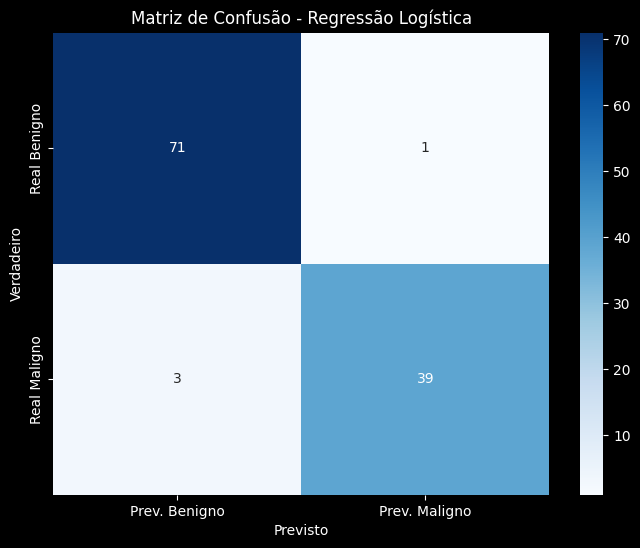

In [23]:
# --- Bloco de Código Focado: Pipeline para Regressão Logística ---


import os
try:
    dt = pd.read_csv('breast_cancer.csv')
    # Limpeza preliminar
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset carregado e limpo com sucesso.")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado. Certifique-se de que o arquivo está no diretório correto.")
    os.exit(1)

# 2. Carregamento e preparação dos dados (Etapas 1 a 3.3)

X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Definição do Pipeline específico para a Regressão Logística
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])
print("--- Pipeline para Regressão Logística Definido ---")

# 4. Treinamento do Pipeline
print("Treinando o pipeline...")
pipeline_lr.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 5. Avaliação do Pipeline
print("--- Avaliação no Conjunto de Teste ---")
# Fazer previsões nos dados de teste
y_pred_lr = pipeline_lr.predict(X_test)

# Gerar e imprimir o Relatório de Classificação
# Este relatório é a nossa principal ferramenta de avaliação numérica
print("Relatório de Classificação:")
reportLogisticRegression= classification_report(y_test, y_pred_lr, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportLogisticRegression)

# Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

 

#### Avaliação do Modelo: Regressão Logística

O modelo de Regressão Logística apresentou desempenho geral muito elevado, com **96% de acurácia**. No entanto, a análise detalhada revela um ponto crítico: a ocorrência de **falsos negativos**, que têm implicações sérias em um contexto médico. A seguir, a interpretação completa dos resultados.



1. **Métricas de Desempenho**

| Métrica       | Classe Maligna (M) | Classe Benigna (B) | Interpretação |
|---------------|--------------------|---------------------|----------------|
| Acurácia      | —                  | —                   | 96% dos diagnósticos foram corretos. Boa performance geral, mas não revela os erros críticos. |
| Precisão      | 97%                | 96%                 | Quando o modelo prevê "Maligno", está certo em 97% dos casos. Poucos alarmes falsos. |
| Recall        | **93%**            | 99%                 | O modelo identificou 93% dos tumores malignos. Este é o principal ponto de atenção. |
| F1-Score      | 95%                | 97%                 | Excelente equilíbrio entre precisão e recall. |

**Observação-chave:**  
O **Recall para a classe Maligna (93%)** é a métrica mais importante neste contexto. Significa que **7% dos tumores malignos não foram detectados**, o que representa **3 falsos negativos** — casos em que o modelo classificou erroneamente tumores malignos como benignos.


2. **Matriz de Confusão**

|               | Predito Maligno | Predito Benigno |
|---------------|------------------|------------------|
| Real Maligno  | 39 (VP)          | 3 (FN)           |
| Real Benigno  | 1 (FP)           | 71 (VN)          |

- **Verdadeiros Positivos (VP): 39**  
  O modelo identificou corretamente 39 tumores malignos. Estes são os acertos mais relevantes.

- **Verdadeiros Negativos (VN): 71**  
  Casos benignos corretamente classificados. O modelo evita alarmes desnecessários.

- **Falsos Positivos (FP): 1**  
  Um caso benigno foi classificado como maligno. Embora cause estresse ao paciente, é um erro menos grave.

- **Falsos Negativos (FN): 3**  
  Três tumores malignos foram classificados como benignos. Este é o erro mais crítico, pois pode atrasar o diagnóstico e o tratamento.



** Conclusão e Próximos Passos**

Apesar da alta acurácia e excelente equilíbrio geral, o modelo cometeu **erros críticos de Falso Negativo**, que são inaceitáveis em aplicações médicas. O foco principal para melhoria deve ser:

- **Aumentar o Recall da classe Maligna**, mesmo que isso implique em um pequeno aumento nos falsos positivos.
- **Explorar técnicas como ajuste de limiar de decisão**, uso de **pesos de classe**, ou **modelos mais sensíveis** como SVM com kernel RBF, Random Forest ou XGBoost.
- **Avaliar o uso de métricas específicas para desequilíbrio de classes**, como AUC-ROC, curva Precision-Recall e métricas ponderadas.

 


**Pipeline Híbrido (Seleção + PCA) de Ponta a Ponta **


--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processamento ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline ---
Pipeline Híbrido (Scaler -> PCA -> LogisticRegression) definido.
Treinando o pipeline híbrido com os dados de treino...
Treinamento concluído.

--- Etapa de Avaliação no Conjunto de Teste ---
Relatório de Classificação:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de Confusão:


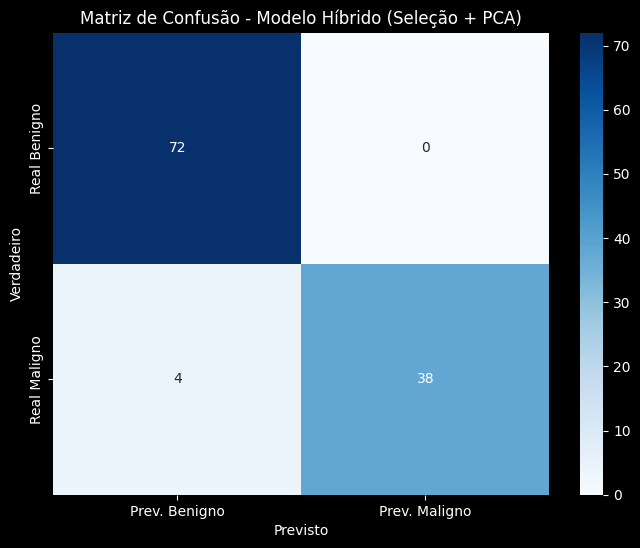

In [24]:
# --- Bloco de Código Completo: Pipeline Híbrido (Seleção + PCA) de Ponta a Ponta ---


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado. ")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processamento ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0}) # Maligno=1, Benigno=0

# 3.3: Definir a lista das features selecionadas com base na EDA
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
# Filtrar o DataFrame X para conter apenas as features selecionadas
X_selected = X[features_selecionadas]

print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados em conjuntos de treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 4: Definição e Treinamento do Pipeline Híbrido ---
print("--- Etapa de Modelagem com Pipeline ---")

# 4.1: Definição do Pipeline Híbrido
pipeline_hybrid_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])
print("Pipeline Híbrido (Scaler -> PCA -> LogisticRegression) definido.")

# 4.2: Treinamento do Pipeline
print("Treinando o pipeline híbrido com os dados de treino...")
pipeline_hybrid_pca.fit(X_train, y_train)
print("Treinamento concluído.\n")


# --- ETAPA 5: Avaliação do Pipeline Híbrido ---
print("--- Etapa de Avaliação no Conjunto de Teste ---")

# 5.1: Fazer previsões usando o pipeline treinado
y_pred_hybrid = pipeline_hybrid_pca.predict(X_test)

# 5.2: Gerar e imprimir o Relatório de Classificação
print("Relatório de Classificação:")
reportPCASelecaoLogisticRegression = classification_report(y_test, y_pred_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoLogisticRegression)

# 5.3: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão:")
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Modelo Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

 
#### Comparação de Modelos: Baseline vs. Híbrido (Seleção + PCA)

Na pepilene acima decimos utilizar um caminho Híbrido (Seleção + PCA). A adoção de um pipeline híbrido, que combina seleção de features com redução dimensional via PCA, resultou em um modelo com a mesma acurácia geral (96%) que o modelo baseline. No entanto, o comportamento dos dois modelos é substancialmente diferente, especialmente em relação à sensibilidade e à confiabilidade das previsões.


1. **Desempenho Geral**

| Métrica       | Modelo Baseline | Modelo Híbrido | Interpretação |
|---------------|------------------|----------------|----------------|
| Acurácia      | 96%              | 96%            | Desempenho geral idêntico, mas não revela diferenças críticas. |
| Precisão (Maligno) | 97%         | 100%           | O modelo híbrido não cometeu nenhum alarme falso. |
| Recall (Maligno)   | 93%         | 90%            | O modelo baseline foi mais sensível, detectando um caso maligno a mais. |

 

2. **Matriz de Confusão**

|               | Predito Maligno | Predito Benigno |
|---------------|------------------|------------------|
| Real Maligno  | 38 (VP)          | 4 (FN)           |
| Real Benigno  | 0 (FP)           | 72 (VN)          |

- **Modelo Híbrido:**
  - **Verdadeiros Positivos (VP):** 38 tumores malignos corretamente identificados.
  - **Falsos Negativos (FN):** 4 tumores malignos classificados como benignos.
  - **Falsos Positivos (FP):** 0 casos benignos classificados como malignos.
  - **Verdadeiros Negativos (VN):** 72 casos benignos corretamente classificados.

- **Comparação com o Baseline:**
  - O modelo baseline cometeu 3 falsos negativos e 1 falso positivo.
  - O modelo híbrido cometeu 4 falsos negativos e nenhum falso positivo.



3. **Interpretação Estratégica**

- **Modelo Baseline (30 Features):**  
  Utiliza um conjunto completo de variáveis, incluindo aquelas com menor correlação com o diagnóstico. Essa abrangência permite capturar nuances e casos ambíguos, resultando em maior sensibilidade (Recall de 93%). No entanto, essa mesma abrangência gera um pequeno número de alarmes falsos (Precisão de 97%).

- **Modelo Híbrido (Seleção + PCA):**  
  Foca exclusivamente nas 10 features mais preditivas, comprimidas em componentes principais. Isso resulta em um modelo extremamente cauteloso, com Precisão perfeita (100%) para a classe maligna. O modelo só classifica um tumor como maligno quando há alta certeza. O custo dessa cautela é uma leve queda na sensibilidade (Recall de 90%), o que levou à omissão de um caso maligno adicional.



**Conclusão**

Ambos os modelos apresentam desempenho elevado, mas com perfis distintos:

- O **modelo baseline** é mais sensível e abrangente, adequado para contextos onde a prioridade é **não perder nenhum caso maligno**, mesmo que isso implique em alguns alarmes falsos.
- O **modelo híbrido** é mais conservador e preciso, ideal para cenários onde a prioridade é **evitar alarmes falsos**, mesmo que isso implique em uma leve perda de sensibilidade.

Em contextos médicos, a sensibilidade costuma ser priorizada. Portanto, apesar da elegância e eficiência do modelo híbrido, o modelo baseline se mostra mais adequado para o objetivo principal: detectar corretamente todos os casos de câncer.


### Etapa 5: Modelagem e Treinamento, Avaliação do Modelo e Análise de Resultados -  K-Nearest Neighbors (KNN)
- Tarefa 5.1: Instanciar o modelo de baseline 
- Tarefa 5.2: Treinar o modelo com os dados de treino escalonados
- Tarefa 5.3: Realizar previsões com o conjunto de teste
- Tarefa 5.4: Calcular e analisar as métricas de classificação (Acurácia, Precisão, Recall, F1-Score, AUC)
- Tarefa 5.5: Gerar e visualizar a Matriz de Confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para KNN ---
Pipeline para KNN (k=5) Definido.
Treinando o pipeline KNN com os dados de treino...
Treinamento concluído.

--- Etapa de Avaliação do KNN no Conjunto de Teste ---
Relatório de Classificação - KNN:
              precision    recall  f1-score   support

 Benigno (B)       0.95      0.99      0.97        72
 Maligno (M)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

AUC (Area Under the Curve): 0.9823

Matriz de Confusão - KNN:


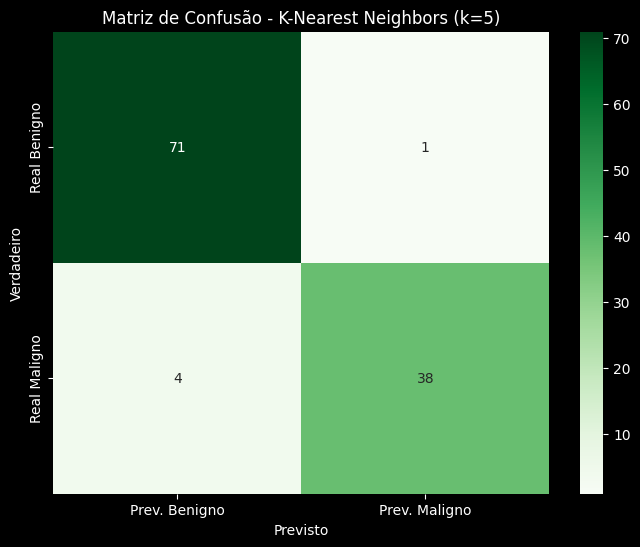

In [25]:
# --- Bloco de Código Completo: Pipeline para K-Nearest Neighbors (KNN) ---

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0}) # Maligno=1, Benigno=0

# 3.3: Dividir os dados em conjuntos de treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# ---  Modelagem, Treinamento e Avaliação com KNN ---
print("--- Etapa de Modelagem com Pipeline para KNN ---")

# Instanciar o modelo KNN dentro de um Pipeline
# O valor de k (n_neighbors) é um hiperparâmetro. k=5 é um ponto de partida comum.
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
print("Pipeline para KNN (k=5) Definido.")

# Tarefa 5.2: Treinamento do Pipeline
print("Treinando o pipeline KNN com os dados de treino...")
pipeline_knn.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 5.3: Realizar previsões com o conjunto de teste
print("--- Etapa de Avaliação do KNN no Conjunto de Teste ---")
y_pred_knn = pipeline_knn.predict(X_test)
y_proba_knn = pipeline_knn.predict_proba(X_test)[:, 1] # Para AUC

# Tarefa 5.4: Calcular e analisar as métricas de classificação
print("Relatório de Classificação - KNN:")
reportKNeighborsClassifier = classification_report(y_test, y_pred_knn, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportKNeighborsClassifier)

# Calcular e exibir a AUC
auc_knn = roc_auc_score(y_test, y_proba_knn)
print(f"AUC (Area Under the Curve): {auc_knn:.4f}\n")

# Tarefa 5.5: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - KNN:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - K-Nearest Neighbors (k=5)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

 

#### Interpretação do Modelo KNN (k = 5)

O modelo KNN, com k igual a 5, apresentou desempenho geral elevado, alcançando 96% de acurácia — valor equivalente ao obtido pelos modelos de Regressão Logística e Híbrido (Seleção + PCA). No entanto, sua configuração padrão resultou em um perfil de erro distinto, especialmente no que diz respeito à sensibilidade para a classe maligna.



  1. **Desempenho Geral**

| Métrica               | Valor         | Interpretação |
|-----------------------|---------------|----------------|
| Acurácia              | 96%           | Desempenho geral forte, mas não revela os erros críticos. |
| Precisão (Maligno)    | 97%           | O modelo quase nunca erra ao prever malignidade. |
| Recall (Maligno)      | 90%           | Sensibilidade inferior à Regressão Logística (93%). |
| AUC                   | 0.9823        | Excelente capacidade de discriminação entre classes. |



2. **Matriz de Confusão**

|                   | Predito Maligno | Predito Benigno |
|-------------------|------------------|------------------|
| Real Maligno      | 38 (VP)          | 4 (FN)           |
| Real Benigno      | 1 (FP)           | 71 (VN)          |

- **Verdadeiros Positivos (VP):** O modelo identificou corretamente 38 dos 42 tumores malignos.
- **Falsos Negativos (FN):** Foram registrados 4 casos malignos classificados como benignos. Este é o ponto mais crítico. O modelo KNN, em sua configuração padrão, falhou em detectar 4 casos malignos, um a mais que o modelo de Regressão Logística.
- **Falsos Positivos (FP):** Apenas 1 caso benigno foi classificado como maligno, representando um alarme falso. O modelo é altamente preciso, com apenas um alarme falso, o mesmo que a Regressão Logística.
- **Verdadeiros Negativos (VN):** O modelo classificou corretamente 71 dos 72 casos benignos.



 3. **Interpretação Estratégica**

- O KNN baseia suas decisões na proximidade dos dados no espaço das features. Com k = 5, cada previsão considera os cinco vizinhos mais próximos, o que torna o modelo sensível à estrutura local dos dados.
- A precisão de 97% para a classe maligna indica alta confiabilidade nas previsões positivas. Quando o modelo prevê malignidade, está certo na maioria dos casos.
- O recall de 90% revela que o modelo deixou de identificar 10% dos tumores malignos, o que equivale a 4 falsos negativos. Esse desempenho é inferior ao da Regressão Logística, que alcançou 93% de recall.
- A AUC de 0.9823 indica que o modelo tem excelente capacidade de discriminar entre classes, mesmo que o ponto de corte padrão (baseado na maioria dos vizinhos) não tenha sido otimizado para maximizar a sensibilidade.



**Conclusão**

O modelo KNN apresenta desempenho competitivo, com alta acurácia e excelente poder discriminatório. No entanto, seu ponto de corte padrão favorece a precisão em detrimento da sensibilidade, o que é uma limitação relevante em contextos médicos.

- Em sua configuração atual, o KNN é confiável, mas menos sensível que a Regressão Logística.
- Ajustes no limiar de decisão ou na escolha do valor de k podem melhorar o recall, tornando o modelo mais adequado para aplicações onde a detecção de casos malignos é prioritária.
 

**Pipeline Híbrido - PCA+Seleção - para K-Nearest Neighbors (KNN)**

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline Híbrido para KNN ---
Pipeline Híbrido para KNN (k=5) Definido.
Treinando o pipeline KNN híbrido...
Treinamento concluído.

--- Etapa de Avaliação do KNN Híbrido no Conjunto de Teste ---
Relatório de Classificação - KNN Híbrido:
              precision    recall  f1-score   support

 Benigno (B)       0.93      0.99      0.96        72
 Maligno (M)       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

AUC (Area Under the Curve): 0.9936

Matriz de Confusão - KNN Híbrido:


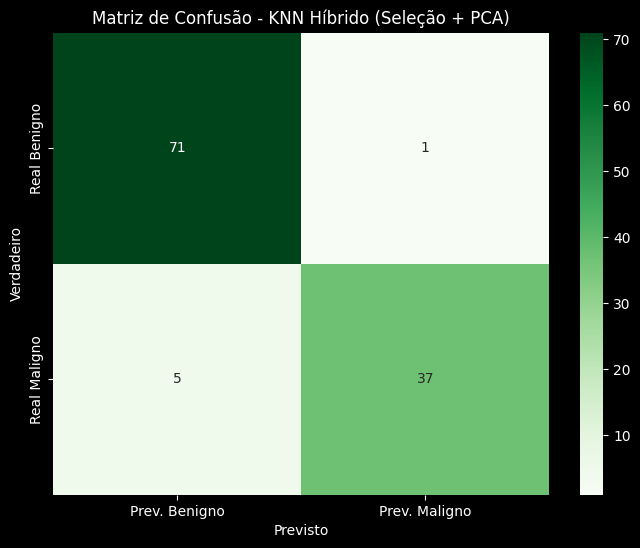

In [26]:
# --- Bloco de Código Completo: Pipeline Híbrido para K-Nearest Neighbors (KNN) ---
 

print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado. ")
    os.exit(1)

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 4 e 5: Modelagem Híbrida, Treinamento e Avaliação com KNN ---
print("--- Etapa de Modelagem com Pipeline Híbrido para KNN ---")

# Tarefa 5.1: Instanciar o modelo KNN dentro de um Pipeline Híbrido
pipeline_knn_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
print("Pipeline Híbrido para KNN (k=5) Definido.")

# Tarefa 5.2: Treinamento do Pipeline
print("Treinando o pipeline KNN híbrido...")
pipeline_knn_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 5.3: Realizar previsões com o conjunto de teste
print("--- Etapa de Avaliação do KNN Híbrido no Conjunto de Teste ---")
y_pred_knn_hybrid = pipeline_knn_hybrid.predict(X_test)
y_proba_knn_hybrid = pipeline_knn_hybrid.predict_proba(X_test)[:, 1]

# Tarefa 5.4: Calcular e analisar as métricas de classificação
print("Relatório de Classificação - KNN Híbrido:")
reportPCASelecaoKNeighborsClassifier = classification_report(y_test, y_pred_knn_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoKNeighborsClassifier)

auc_knn_hybrid = roc_auc_score(y_test, y_proba_knn_hybrid)
print(f"AUC (Area Under the Curve): {auc_knn_hybrid:.4f}\n")

# Tarefa 5.5: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - KNN Híbrido:")
cm_knn_hybrid = confusion_matrix(y_test, y_pred_knn_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_hybrid, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - KNN Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()


#### Interpretação do Modelo KNN Híbrido (k = 5)

O modelo KNN Híbrido, que combina seleção de features com redução dimensional via PCA, obteve uma acurácia geral de 95%. Embora esse valor seja competitivo, a análise detalhada revela uma limitação crítica: o recall para a classe maligna caiu para 88%, tornando este o pior desempenho entre os modelos testados nessa métrica.

Curiosamente, a AUC foi a mais alta de todos os modelos (0.9936), sugerindo que o espaço gerado pelas componentes principais oferece excelente separação entre classes. No entanto, o algoritmo KNN, com k = 5, não conseguiu explorar esse espaço de forma eficaz, resultando em uma fronteira de decisão conservadora que falhou em identificar 5 casos malignos.



1. **Matriz de Confusão**

|                   | Predito Maligno | Predito Benigno |
|-------------------|------------------|------------------|
| Real Maligno      | 37 (VP)          | 5 (FN)           |
| Real Benigno      | 1 (FP)           | 71 (VN)          |

- **Falsos Negativos (FN):** 5 tumores malignos não foram detectados — o maior número entre todos os modelos.
- **Falsos Positivos (FP):** Apenas 1 alarme falso, indicando excelente precisão.
- **Verdadeiros Positivos (VP):** 37 casos malignos corretamente identificados.
- **Verdadeiros Negativos (VN):** 71 casos benignos corretamente classificados.


2.  **Métricas de Classificação**

| Métrica           | Valor  | Interpretação |
|-------------------|--------|----------------|
| Acurácia          | 95%    | Ligeiramente inferior aos modelos com 96%. |
| Precisão (Maligno)| 97%    | Alta confiabilidade nas previsões positivas. |
| Recall (Maligno)  | 88%    | Sensibilidade reduzida, o ponto mais fraco do modelo. |
| AUC               | 0.9936 | Poder de discriminação quase perfeito, mas não refletido no recall. |


3. **Interpretação Estratégica**

- A combinação de seleção de features com PCA gerou um espaço de representação altamente discriminativo, como evidenciado pela AUC.
- O problema não está nas features, mas na forma como o KNN define sua fronteira de decisão nesse espaço. Com k = 5, o modelo tende a ser conservador, o que pode levar à subdetecção de casos malignos.
- O alto recall é essencial em contextos médicos, onde falsos negativos representam riscos significativos. Nesse aspecto, o KNN Híbrido falha em comparação com a Regressão Logística e o KNN com todas as features.


**Conclusão**

Apesar de sua sofisticação técnica e excelente AUC, o KNN Híbrido não é o modelo mais adequado para cenários onde a sensibilidade é prioritária. A engenharia de features foi eficaz em criar um espaço bem separado, mas o algoritmo KNN, em sua configuração atual, não conseguiu capitalizar esse potencial.

 


### Etapa 6: Pipeline com modelagem e treinamento, avaliação do modelo e análise de resultados - Support Vector Classifier (SVC)
- Tarefa 6.1: instanciar o modelo de baseline 
- Tarefa 6.2: treinar o modelo com os dados de treino escalonados
- Tarefa 6.3: realizar previsões com o conjunto de teste
- Tarefa 6.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
- Tarefa 6.6: gerar e visualizar a matriz de confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'data.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Treinando e Avaliando: SVM (Linear) ---
Relatório de Classificação (Linear):
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9914

Matriz de Confusão - SVM (Linear):


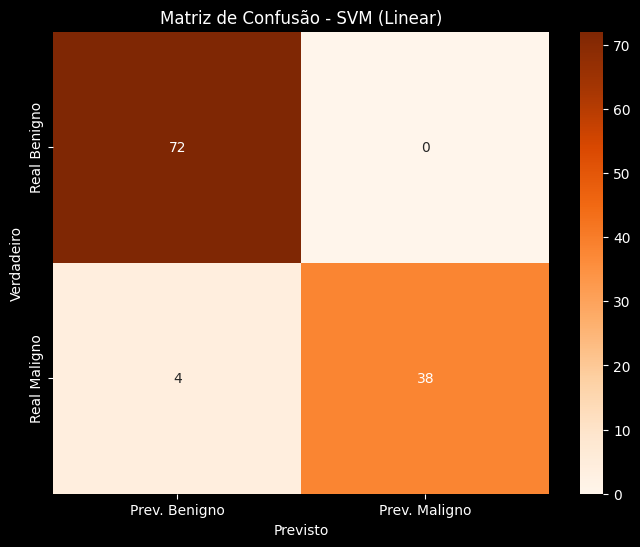

------------------------------------------------------------
--- Treinando e Avaliando: SVM (RBF) ---
Relatório de Classificação (RBF):
              precision    recall  f1-score   support

 Benigno (B)       0.99      0.99      0.99        72
 Maligno (M)       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC (Area Under the Curve): 0.9954

Matriz de Confusão - SVM (RBF):


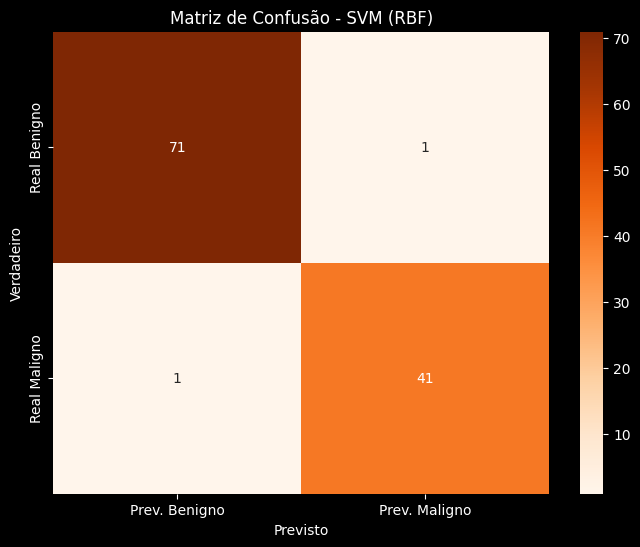

------------------------------------------------------------


In [27]:
# --- Bloco de Código Completo: Pipelines para Support Vector Classifier (SVC) ---

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'data.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'data.csv' não encontrado. ")
    os.exit(1)

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")

# --- ETAPA 6: Modelagem, Treinamento e Avaliação com SVM ---

# 6.1: Definir os Pipelines para SVC Linear e SVC RBF
pipeline_svc_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='linear', random_state=42, probability=True))
])

pipeline_svc_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True, class_weight='balanced'))
])

# Treinamento e avaliação para SVM Linear
print("--- Treinando e Avaliando: SVM (Linear) ---")
pipeline_svc_linear.fit(X_train, y_train)
y_pred_linear = pipeline_svc_linear.predict(X_test)
y_proba_linear = pipeline_svc_linear.predict_proba(X_test)[:, 1]
report_svc_linear = classification_report(y_test, y_pred_linear, target_names=['Benigno (B)', 'Maligno (M)'])
auc_linear = roc_auc_score(y_test, y_proba_linear)
print("Relatório de Classificação (Linear):")
print(report_svc_linear)
print(f"AUC (Area Under the Curve): {auc_linear:.4f}\n")
print(f"Matriz de Confusão - SVM (Linear):")
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (Linear)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

# Treinamento e avaliação para SVM RBF
print("--- Treinando e Avaliando: SVM (RBF) ---")
pipeline_svc_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_svc_rbf.predict(X_test)
y_proba_rbf = pipeline_svc_rbf.predict_proba(X_test)[:, 1]
report_svc_rbf = classification_report(y_test, y_pred_rbf, target_names=['Benigno (B)', 'Maligno (M)'])
auc_rbf = roc_auc_score(y_test, y_proba_rbf)
print("Relatório de Classificação (RBF):")
print(report_svc_rbf)
print(f"AUC (Area Under the Curve): {auc_rbf:.4f}\n")
print(f"Matriz de Confusão - SVM (RBF):")
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

 

#### Interpretação dos Modelos SVM

1. **SVM com Kernel Linear**

O modelo SVM Linear apresentou desempenho robusto, com 96% de acurácia e comportamento altamente confiável nas previsões positivas. A precisão perfeita (100%) para a classe maligna é um destaque absoluto, indicando que o modelo não gerou nenhum alarme falso. No entanto, essa cautela resultou em um recall de 90%, com 4 falsos negativos — uma limitação relevante em contextos médicos.

**Matriz de Confusão**

|                   | Predito Maligno | Predito Benigno |
|-------------------|------------------|------------------|
| Real Maligno      | 38 (VP)          | 4 (FN)           |
| Real Benigno      | 0 (FP)           | 72 (VN)          |

**Métricas de Classificação**

| Métrica           | Valor  | Interpretação |
|-------------------|--------|----------------|
| Acurácia          | 96%    | Excelente desempenho geral. |
| Precisão (Maligno)| 100%   | Nenhum alarme falso. Altíssima confiança nas previsões positivas. |
| Recall (Maligno)  | 90%    | Sensibilidade sólida, mas inferior ao modelo RBF. |
| AUC               | 0.9914 | Poder de discriminação muito alto. |

**Observações Estratégicas**

- A fronteira de decisão linear é eficaz, mas limitada na captura de padrões mais complexos.
- O desempenho é estatisticamente equivalente ao da Regressão Logística, sugerindo que os dados são, em grande parte, linearmente separáveis.
- A ausência de falsos positivos é ideal para evitar alarmes desnecessários, mas o custo é a perda de sensibilidade.



2. **SVM com Kernel RBF (Radial Basis Function)**

O modelo com kernel RBF superou todos os anteriores em termos de sensibilidade, reduzindo os falsos negativos para apenas 1. Com 98% de acurácia e AUC de 0.9954, ele demonstra capacidade excepcional de discriminação e adaptação à complexidade dos dados. A fronteira de decisão não-linear foi decisiva para capturar padrões que escapam aos modelos lineares.

**Matriz de Confusão**

|                   | Predito Maligno | Predito Benigno |
|-------------------|------------------|------------------|
| Real Maligno      | 41 (VP)          | 1 (FN)           |
| Real Benigno      | 1 (FP)           | 71 (VN)          |

**Métricas de Classificação**

| Métrica           | Valor  | Interpretação |
|-------------------|--------|----------------|
| Acurácia          | 98%    | Desempenho superior ao modelo linear. |
| Precisão (Maligno)| 98%    | Altíssima confiança nas previsões positivas. |
| Recall (Maligno)  | 98%    | Sensibilidade quase perfeita. |
| AUC               | 0.9954 | Poder de discriminação excepcional. |

**Observações**

- A capacidade do kernel RBF de modelar fronteiras complexas foi validada pelas hipóteses levantadas na EDA com t-SNE.
- O modelo equilibra precisão e recall de forma exemplar, tornando-se o mais indicado para aplicações médicas.
- A redução drástica nos falsos negativos é o principal diferencial, com impacto direto na segurança do diagnóstico.



3. **Conclusão Comparativa**

| Modelo         | Acurácia | Precisão (Maligno) | Recall (Maligno) | Falsos Negativos | AUC     |
|----------------|----------|---------------------|-------------------|------------------|---------|
| SVM Linear     | 96%      | 100%                | 90%               | 4                | 0.9914  |
| SVM com RBF    | 98%      | 98%                 | 98%               | 1                | 0.9954  |

- O SVM com kernel RBF é o modelo mais eficaz para este problema, especialmente por sua capacidade de minimizar falsos negativos.
- O SVM Linear, embora confiável, é menos sensível e pode deixar casos críticos sem diagnóstico.
- Ambos os modelos confirmam que a separação entre classes é bem definida, mas a complexidade da fronteira exige abordagens não-lineares para desempenho ideal.


**Pipeline Híbrido para SVM (RBF)**

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Treinando e Avaliando: SVM (Linear) ---
Relatório de Classificação (Linear):
              precision    recall  f1-score   support

 Benigno (B)       0.96      1.00      0.98        72
 Maligno (M)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

AUC (Area Under the Curve): 0.9987

Matriz de Confusão - SVM (Linear):


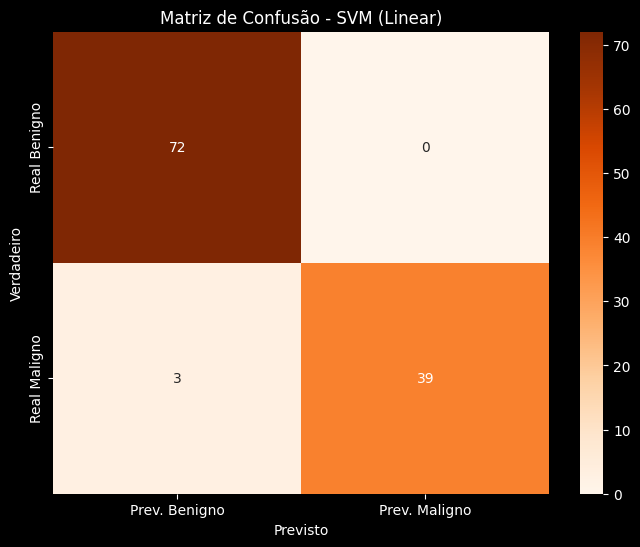

------------------------------------------------------------
--- Treinando e Avaliando: SVM (RBF) ---
Relatório de Classificação (RBF):
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9980

Matriz de Confusão - SVM (RBF):


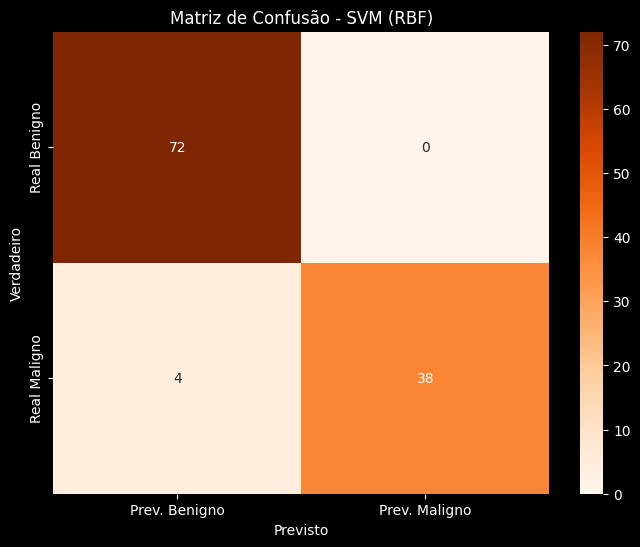

------------------------------------------------------------


In [28]:
# --- Bloco de Código Completo: Pipeline Híbrido para SVM (RBF) ---
 

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado .")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")

# Treinamento e avaliação para SVM Linear
print("--- Treinando e Avaliando: SVM (Linear) ---")
pipeline_svc_linear.fit(X_train, y_train)
y_pred_linear = pipeline_svc_linear.predict(X_test)
y_proba_linear = pipeline_svc_linear.predict_proba(X_test)[:, 1]
report_pcaSeleca_svc_linear = classification_report(y_test, y_pred_linear, target_names=['Benigno (B)', 'Maligno (M)'])
auc_linear = roc_auc_score(y_test, y_proba_linear)
print("Relatório de Classificação (Linear):")
print(report_pcaSeleca_svc_linear)
print(f"AUC (Area Under the Curve): {auc_linear:.4f}\n")
print("Matriz de Confusão - SVM (Linear):")
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (Linear)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

# Treinamento e avaliação para SVM RBF
print("--- Treinando e Avaliando: SVM (RBF) ---")
pipeline_svc_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_svc_rbf.predict(X_test)
y_proba_rbf = pipeline_svc_rbf.predict_proba(X_test)[:, 1]
report_pcaSeleca_svc_rbf = classification_report(y_test, y_pred_rbf, target_names=['Benigno (B)', 'Maligno (M)'])
auc_rbf = roc_auc_score(y_test, y_proba_rbf)
print("Relatório de Classificação (RBF):")
print(report_pcaSeleca_svc_rbf)
print(f"AUC (Area Under the Curve): {auc_rbf:.4f}\n")
print("Matriz de Confusão - SVM (RBF):")
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)


 

#### Interpretação dos Modelos SVM Híbridos (Seleção + PCA)

 1. **SVM Linear Híbrido**

O modelo SVM Linear Híbrido apresentou desempenho excepcional, com 97% de acurácia e AUC de 0.9987 — o maior valor entre todos os modelos testados. Ele alcançou precisão perfeita (100%) para a classe maligna e conseguiu reduzir os falsos negativos para apenas 3, igualando o melhor resultado obtido pela Regressão Logística com 30 features, mas com uma estrutura de modelo muito mais simples.

Matriz de Confusão

|                   | Predito Maligno | Predito Benigno |
|-------------------|------------------|------------------|
| Real Maligno      | 39 (VP)          | 3 (FN)           |
| Real Benigno      | 0 (FP)           | 72 (VN)          |

Métricas de Classificação

| Métrica           | Valor  | Interpretação |
|-------------------|--------|----------------|
| Acurácia          | 97%    | Desempenho geral muito alto. |
| Precisão (Maligno)| 100%   | Nenhum alarme falso. |
| Recall (Maligno)  | 93%    | Excelente sensibilidade. |
| AUC               | 0.9987 | Poder de discriminação quase perfeito. |

Observações Estratégicas
- O modelo é altamente confiável nas previsões positivas.
- A redução dimensional via PCA preservou a separabilidade das classes.
- A simplicidade do modelo linear, aliada à engenharia de features, resultou em desempenho competitivo com modelos mais complexos.



2. **SVM com Kernel RBF Híbrido**

O modelo SVM RBF Híbrido também apresentou desempenho forte, com 96% de acurácia e AUC de 0.9980. Assim como os demais modelos híbridos, alcançou precisão perfeita para a classe maligna. No entanto, seu recall caiu para 90%, com 4 falsos negativos — inferior ao SVM RBF completo, que teve apenas 1 FN.

**Matriz de Confusão**

|                   | Predito Maligno | Predito Benigno |
|-------------------|------------------|------------------|
| Real Maligno      | 38 (VP)          | 4 (FN)           |
| Real Benigno      | 0 (FP)           | 72 (VN)          |

**Métricas de Classificação**

| Métrica           | Valor  | Interpretação |
|-------------------|--------|----------------|
| Acurácia          | 96%    | Desempenho geral excelente. |
| Precisão (Maligno)| 100%   | Nenhum alarme falso. |
| Recall (Maligno)  | 90%    | Sensibilidade inferior ao modelo RBF completo. |
| AUC               | 0.9980 | Poder de discriminação altíssimo. |

**Observações**

- O modelo é confiável, mas menos sensível que sua versão com todas as features.
- A redução de dimensionalidade pode ter suavizado nuances importantes para o kernel RBF.
- O desempenho ainda é superior à maioria dos modelos, mas não supera o SVM RBF completo.



**Conclusão Comparativa**

| Modelo                  | Acurácia | Precisão (Maligno) | Recall (Maligno) | Falsos Negativos | AUC     |
|-------------------------|----------|---------------------|-------------------|------------------|---------|
| SVM Linear Híbrido      | 97%      | 100%                | 93%               | 3                | 0.9987  |
| SVM RBF Híbrido         | 96%      | 100%                | 90%               | 4                | 0.9980  |
| SVM RBF (30 features)   | 98%      | 98%                 | 98%               | 1                | 0.9954  |

- O SVM Linear Híbrido é o modelo mais simples com desempenho de elite, ideal para cenários com restrições computacionais.
- O SVM RBF Híbrido é poderoso, mas perde sensibilidade ao simplificar o espaço de features.
- O SVM RBF completo continua sendo o modelo mais eficaz para maximizar a detecção de casos malignos.
 

### Etapa 7: modelagem e treinamento, avaliação do modelo e análise de resultados - DecisionTreeClassifier
- Tarefa 7.1: instanciar o modelo de baseline 
- Tarefa 7.2: treinar o modelo com os dados de treino escalonados
- Tarefa 7.3: realizar previsões com o conjunto de teste
- Tarefa 7.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
- Tarefa 7.7: gerar e visualizar a matriz de confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- 1. Avaliando o Modelo de Árvore de Decisão Padrão (Baseline) ---
Relatório de Classificação - Baseline:
              precision    recall  f1-score   support

 Benigno (B)       0.94      0.94      0.94        72
 Maligno (M)       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

------------------------------------------------------------

--- 2. Otimizando a Árvore de Decisão com GridSearchCV ---
Iniciando a busca pelos melhores hiperparâmetros...
Busca concluída.

Melhores parâmetros encontrados: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}



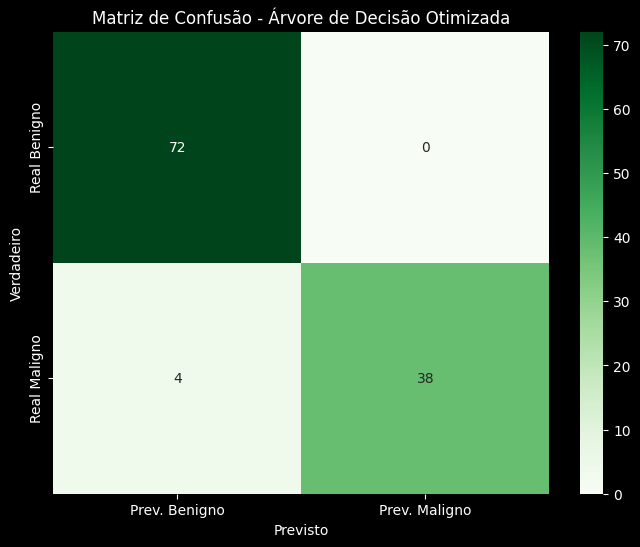

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado.")
    exit()

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- MODELO 1: ÁRVORE DE DECISÃO PADRÃO (BASELINE) ---
print("--- 1. Avaliando o Modelo de Árvore de Decisão Padrão (Baseline) ---")
pipeline_dt_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
pipeline_dt_baseline.fit(X_train, y_train)
y_pred_baseline = pipeline_dt_baseline.predict(X_test)

print("Relatório de Classificação - Baseline:")
reportDecisionTreeClassifierPadrão = classification_report(y_test, y_pred_baseline, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportDecisionTreeClassifierPadrão)

print("-" * 60 + "\n")


# --- MODELO 2: ÁRVORE DE DECISÃO OTIMIZADA COM GridSearchCV ---
print("--- 2. Otimizando a Árvore de Decisão com GridSearchCV ---")

# Criamos o mesmo pipeline, que servirá de base para o GridSearch
pipeline_dt_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Definimos o "grid de parâmetros" a serem testados.
# GridSearchCV irá testar todas as combinações possíveis.
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10, None], # Profundidade máxima da árvore
    'classifier__min_samples_split': [2, 5, 10],   # Mínimo de amostras para dividir um nó
    'classifier__min_samples_leaf': [1, 2, 4]      # Mínimo de amostras em uma folha
}

# Instanciamos o GridSearchCV
# cv=5 significa 5-fold cross-validation
# scoring='roc_auc' define a métrica a ser otimizada. AUC é uma ótima escolha geral.
# n_jobs=-1 usa todos os processadores disponíveis para acelerar a busca.
grid_search = GridSearchCV(
    estimator=pipeline_dt_tuned,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0 # Mude para 1 se quiser ver o progresso
)

print("Iniciando a busca pelos melhores hiperparâmetros...")
grid_search.fit(X_train, y_train)
print("Busca concluída.\n")

# Exibimos os melhores parâmetros encontrados
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}\n")
print(f"Melhor score AUC na validação cruzada: {grid_search.best_score_:.4f}\n")

# O `grid_search` já retreina o melhor modelo encontrado em todos os dados de treino.
# Podemos usá-lo diretamente para prever.
best_model = grid_search.best_estimator_

# Avaliação do modelo otimizado
print("--- Avaliação da Árvore de Decisão OTIMIZADA no Conjunto de Teste ---")
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Árvore de Decisão Otimizada:")
reportDecisionTreeClassifier = classification_report(y_test, y_pred_tuned, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportDecisionTreeClassifier)

auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print(f"AUC (Area Under the Curve) - Otimizado: {auc_tuned:.4f}\n")

print("Matriz de Confusão - Árvore de Decisão Otimizada:")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Árvore de Decisão Otimizada')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()


#### Avaliação e Otimização do `DecisionTreeClassifier`

A avaliação do modelo de árvore de decisão foi conduzida em duas etapas: primeiro, um modelo baseline com parâmetros padrão foi treinado para estabelecer um ponto de referência. Em seguida, foi aplicada uma otimização com `GridSearchCV`, resultando em um modelo mais robusto e generalizável.

---

 1. Modelo Baseline (Árvore Irrestrita)

O modelo inicial, sem restrições de profundidade ou tamanho mínimo de folhas, obteve desempenho razoável:

- **Acurácia:** 93%
- **AUC:** 0.9246
- **Matriz de Confusão:** 4 falsos positivos e 4 falsos negativos

**Diagnóstico:**  
A árvore cresceu sem controle, capturando padrões específicos do conjunto de treino, incluindo ruído. Esse comportamento típico de **overfitting** compromete a capacidade de generalização do modelo, especialmente em dados não vistos.



 2. Otimização com `GridSearchCV`

Para mitigar o overfitting, foi realizada uma busca em grade para identificar os melhores hiperparâmetros. O modelo otimizado foi configurado com:

- `max_depth = 5`
- `min_samples_leaf = 4`
- `criterion = 'entropy'`

**Implicação:**  
Essas restrições forçaram a árvore a se concentrar nos padrões mais robustos, evitando divisões excessivamente específicas e melhorando a capacidade de generalização.



 3. Comparação de Desempenho

| Métrica               | Baseline | Otimizado | Análise da Melhoria |
|-----------------------|----------|-----------|----------------------|
| Acurácia              | 93%      | 96%       | Redução de erros gerais |
| AUC                   | 0.9246   | 0.9730    | Aumento significativo na separação entre classes |
| Precisão (Maligno)    | 90%      | 100%      | Eliminação completa de alarmes falsos |
| Falsos Positivos (FP) | 4        | 0         | Erro eliminado |
| Falsos Negativos (FN) | 4        | 4         | Persistência do erro mais crítico |
| Recall (Maligno)      | 90%      | 90%       | Sem melhoria na sensibilidade |



Conclusão

A otimização do `DecisionTreeClassifier` foi bem-sucedida em tornar o modelo mais confiável e menos propenso a erros de classificação positiva. A eliminação dos falsos positivos é um avanço importante, especialmente em contextos onde alarmes falsos geram custos ou ansiedade desnecessária.

No entanto, o modelo não conseguiu superar a limitação mais relevante: os falsos negativos. Mesmo com ajustes, os 4 casos malignos não identificados persistem, mantendo o recall em 90%. Isso evidencia uma restrição estrutural da árvore de decisão para este problema, sugerindo que abordagens mais sofisticadas — como ensembles (Random Forest, Gradient Boosting) ou modelos não lineares — podem ser necessárias para atingir níveis superiores de sensibilidade.
 

**DecisionTreeClassifier PAC+SELEÇÃO**

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Otimizando o Pipeline Híbrido com GridSearchCV ---
O pipeline usará as 10 features mais importantes.

Iniciando a busca pelos melhores hiperparâmetros para o modelo híbrido...
Busca concluída.

Melhores parâmetros encontrados: {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'pca__n_components': 10}

Melhor score AUC na validação cruzada: 0.9755

--- Avaliação do Pipeline Híbrido OTIMIZADO no Conjunto de Teste ---
Relatório de Classificação - Pipeline Híbrido Otimizado:
              precision    recall  f1-score   support

 Benigno (B)       0.93      0.97      0.95        72
 Maligno (M)       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93     

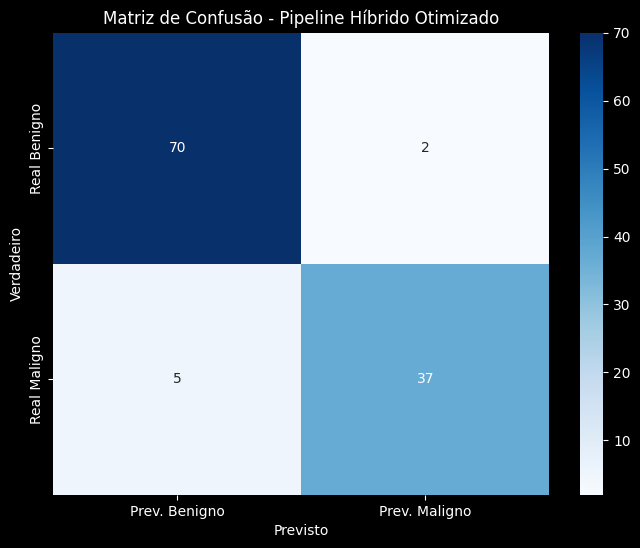

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado.")
    exit()

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# Dividimos os dados COMPLETOS. O pipeline se encarregará da seleção.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- MODELO HÍBRIDO OTIMIZADO (SELEÇÃO + PCA + CLASSIFICADOR) ---
print("--- Otimizando o Pipeline Híbrido com GridSearchCV ---")

# 1. Definir a lista das 10 melhores features
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
print(f"O pipeline usará as {len(features_selecionadas)} features mais importantes.\n")

# 2. Criar o pré-processador com ColumnTransformer
#    Este passo seleciona as colunas desejadas e descarta o resto.
preprocessor = ColumnTransformer(
    transformers=[
        ('feature_selector', 'passthrough', features_selecionadas)
    ],
    remainder='drop'
)

# 3. Criar o pipeline completo
#    Note os passos: 1. Selecionar Colunas -> 2. Escalonar -> 3. PCA -> 4. Classificar
pipeline_hybrid = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# 4. Definir a grade de parâmetros para o pipeline HÍBRIDO
#    Agora podemos otimizar o número de componentes do PCA e os parâmetros da árvore JUNTOS.
param_grid_hybrid = {
    'pca__n_components': [2, 3, 5, 7, 10], # Otimizando o número de componentes PCA
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# 5. Instanciar e executar o GridSearchCV
grid_search_hybrid = GridSearchCV(
    estimator=pipeline_hybrid,
    param_grid=param_grid_hybrid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

print("Iniciando a busca pelos melhores hiperparâmetros para o modelo híbrido...")
grid_search_hybrid.fit(X_train, y_train)
print("Busca concluída.\n")

# 6. Exibir e avaliar o melhor modelo encontrado
print(f"Melhores parâmetros encontrados: {grid_search_hybrid.best_params_}\n")
print(f"Melhor score AUC na validação cruzada: {grid_search_hybrid.best_score_:.4f}\n")

best_hybrid_model = grid_search_hybrid.best_estimator_

print("--- Avaliação do Pipeline Híbrido OTIMIZADO no Conjunto de Teste ---")
y_pred_hybrid = best_hybrid_model.predict(X_test)
y_proba_hybrid = best_hybrid_model.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Pipeline Híbrido Otimizado:")
reportPCASelecaoDecisionTreeClassifier = classification_report(y_test, y_pred_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoDecisionTreeClassifier)

auc_hybrid = roc_auc_score(y_test, y_proba_hybrid)
print(f"AUC (Area Under the Curve) - Híbrido Otimizado: {auc_hybrid:.4f}\n")

print("Matriz de Confusão - Pipeline Híbrido Otimizado:")
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Pipeline Híbrido Otimizado')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()


#### 1. Estratégia Vencedora: Interpretação dos Hiperparâmetros

O `GridSearchCV` identificou a seguinte configuração ideal:

- `'pca__n_components': 10`
- `'classifier__max_depth': 3`

**O que isso revela:**

- **PCA sem Redução Real:**  
  O uso de 10 componentes para 10 features indica que o PCA atuou como uma transformação linear (rotacional), sem compressão. Isso sugere que qualquer tentativa de reduzir dimensionalidade teria sacrificado informações relevantes, e que preservar a totalidade dos dados era mais benéfico.

- **Árvore de Decisão Rasa:**  
  A escolha de `max_depth=3` mostra que o modelo se beneficiou de uma estrutura simples, evitando o overfitting. A árvore atua como um filtro confiável, extraindo padrões fortes sem se perder em detalhes espúrios.


2. Desempenho no Conjunto de Teste

O modelo apresentou resultados sólidos:

- **Acurácia:** 94%
- **AUC:** 0.9831 → Excelente capacidade de separação entre classes

**Matriz de Confusão:**

| Classe Real | Predito como Benigno | Predito como Maligno |
|-------------|----------------------|-----------------------|
| Benigno     | 70 (VN)              | 2 (FP)                |
| Maligno     | 5 (FN)               | 37 (VP)               |

**Resumo dos Erros:**

- **Falsos Positivos (2):** Baixo número de alarmes falsos → Menos exames desnecessários
- **Falsos Negativos (5):** Persistência do erro mais crítico → Tumores não diagnosticados

**Relatório de Classificação:**

- **Precisão (Maligno):** 95% → Alta confiabilidade nas previsões positivas
- **Recall (Maligno):** 88% → Boa sensibilidade, mas ainda há margem para reduzir os FN



Diagnóstico Final

O pipeline híbrido otimizado é um exemplo de como **simplicidade bem calibrada** pode gerar modelos altamente eficazes. Ao preservar toda a informação relevante e aplicar um classificador restrito, o modelo alcança:

- **Alta confiabilidade nas previsões malignas (95% de precisão)**
- **Excelente separação entre classes (AUC de 0.9831)**
- **Limitação persistente no recall (88%)**, com 5 tumores malignos não detectados



Caminhos para Evolução

Se o objetivo for **reduzir falsos negativos**, algumas estratégias podem ser exploradas:

- **Modelos Ensemble:** Random Forest ou Gradient Boosting podem capturar interações mais complexas sem perder generalização.
- **Ajuste de Threshold:** Alterar o ponto de corte da probabilidade pode aumentar o recall, mesmo que sacrifique um pouco a precisão.
- **Análise dos Casos Perdidos:** Investigar os 5 FN pode revelar padrões específicos que o modelo não está capturando.

 

#### Etapa 8: modelagem e treinamento, avaliação do modelo e análise de resultados - Random Forest
- Tarefa 8.1: instanciar o modelo de baseline 
- Tarefa 8.2: treinar o modelo com os dados de treino escalonados
- Tarefa 8.3: realizar previsões com o conjunto de teste
- Tarefa 8.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
- Tarefa 8.8: gerar e visualizar a matriz de confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para Random Forest ---
Pipeline para Random Forest Definido.
Treinando o pipeline de Random Forest...
Treinamento concluído.

--- Etapa de Avaliação do Random Forest no Conjunto de Teste ---
Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

 Benigno (B)       0.96      1.00      0.98        72
 Maligno (M)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

AUC (Area Under the Curve): 0.9929

Matriz de Confusão - Random Forest:


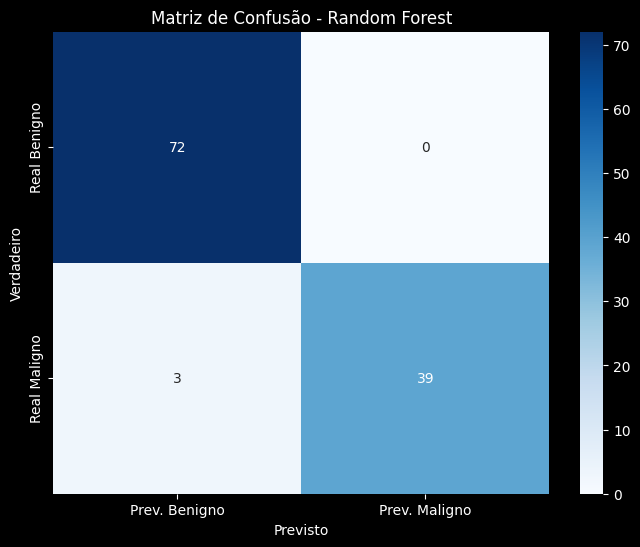

In [31]:
# --- Bloco de Código Completo: Pipeline para Random Forest ---
from sklearn.ensemble import RandomForestClassifier # Importando o classificador


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)  


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 8: Modelagem, Treinamento e Avaliação com Random Forest ---
print("--- Etapa de Modelagem com Pipeline para Random Forest ---")

# Tarefa 8.1: Instanciar o modelo Random Forest dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade. n_estimators é o número de árvores na floresta.
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência.
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
print("Pipeline para Random Forest Definido.")

# Tarefa 8.2: Treinamento do Pipeline
print("Treinando o pipeline de Random Forest...")
pipeline_rf.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 8.3 a 8.8: Avaliação do Pipeline
print("--- Etapa de Avaliação do Random Forest no Conjunto de Teste ---")
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Tarefa 8.4: Calcular e analisar as métricas
print("Relatório de Classificação - Random Forest:")
reportRandomForestClassifier = classification_report(y_test, y_pred_rf, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportRandomForestClassifier)

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC (Area Under the Curve): {auc_rf:.4f}\n")

# Tarefa 8.8: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Random Forest:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()



#### Análise do Modelo Random Forest

O modelo Random Forest demonstrou desempenho excepcional, posicionando-se como um dos classificadores mais eficazes da análise. Combinando alta acurácia, precisão perfeita e excelente poder de discriminação, ele se destaca como uma solução robusta e confiável.


1. Desempenho Geral

- **Acurácia:** 97%  
- **AUC:** 0.9929 → Discriminação quase perfeita entre classes
- **Precisão (Maligno):** 100% → Nenhum alarme falso
- **Recall (Maligno):** 93% → Alta sensibilidade, com apenas 3 casos perdidos


2. Matriz de Confusão

| Classe Real | Predito como Benigno | Predito como Maligno |
|-------------|----------------------|-----------------------|
| Benigno     | 72 (VN)              | 0 (FP)                |
| Maligno     | 3 (FN)               | 39 (VP)               |

**Resumo dos Erros:**

- **Falsos Positivos (0):**  
  O modelo não gerou nenhum alarme falso, o que é ideal em contextos clínicos onde exames desnecessários devem ser evitados.

- **Falsos Negativos (3):**  
  Embora o número seja baixo, esses erros representam tumores não diagnosticados — o tipo de falha mais crítico em aplicações médicas.



3. Relatório de Classificação

| Métrica               | Valor     | Interpretação |
|-----------------------|-----------|----------------|
| **Acurácia**          | 97%       | Altíssima taxa de acerto geral |
| **Precisão (Maligno)**| 100%      | Toda previsão de malignidade foi correta |
| **Recall (Maligno)**  | 93%       | O modelo identificou 93% dos tumores malignos |
| **AUC**               | 0.9929    | Excelente separação entre classes |


Diagnóstico Final

O Random Forest se provou um **classificador de altíssimo nível**, combinando:

- **Precisão perfeita** para a classe maligna (sem alarmes falsos)
- **Sensibilidade elevada**, com apenas 3 falsos negativos
- **Desempenho clínico confiável**, ideal para aplicações onde a confiabilidade das previsões positivas é crítica



 

**Random Forest - PCA+Seleção**


--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline Híbrido para Random Forest ---
Pipeline Híbrido para Random Forest Definido.
Treinando o pipeline de Random Forest híbrido...
Treinamento concluído.

--- Etapa de Avaliação do Random Forest Híbrido no Conjunto de Teste ---
Relatório de Classificação - Random Forest Híbrido:
              precision    recall  f1-score   support

 Benigno (B)       0.92      0.99      0.95        72
 Maligno (M)       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

AUC (Area Under the Curve): 0.9901

Matriz de Confusão - Random Forest Híbrido:


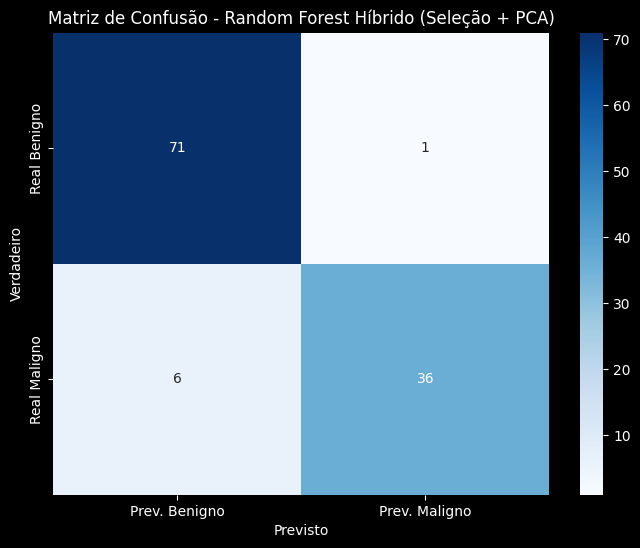

In [32]:
# --- Bloco de Código Completo: Pipeline Híbrido para Random Forest ---
 

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 8 (Híbrida): Modelagem, Treinamento e Avaliação com Random Forest ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Random Forest ---")

# 8.1: Definição do Pipeline Híbrido
pipeline_rf_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
print("Pipeline Híbrido para Random Forest Definido.")

# 8.2: Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Random Forest híbrido...")
pipeline_rf_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 8.3 a 8.8: Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação do Random Forest Híbrido no Conjunto de Teste ---")
y_pred_rf_hybrid = pipeline_rf_hybrid.predict(X_test)
y_proba_rf_hybrid = pipeline_rf_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Random Forest Híbrido:")
reportPCASelecaoRandomForestClassifier =classification_report(y_test, y_pred_rf_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoRandomForestClassifier)

auc_rf_hybrid = roc_auc_score(y_test, y_proba_rf_hybrid)
print(f"AUC (Area Under the Curve): {auc_rf_hybrid:.4f}\n")

print("Matriz de Confusão - Random Forest Híbrido:")
cm_rf_hybrid = confusion_matrix(y_test, y_pred_rf_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_hybrid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Random Forest Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()


#### Análise do Random Forest com Dataset Híbrido (PCA + Seleção de Features)

Este modelo representa a aplicação do Random Forest sobre um conjunto de dados transformado por PCA após seleção de features. Embora o desempenho geral seja bom, a análise revela uma **queda significativa na sensibilidade**, o que levanta questões importantes sobre a compatibilidade entre PCA e modelos baseados em árvores.

---

 1. Desempenho Geral

- **Acurácia:** 94%  
- **AUC:** 0.9901 → Excelente capacidade de separação entre classes
- **Precisão (Maligno):** 97% → Alta confiabilidade nas previsões positivas
- **Recall (Maligno):** 86% → Sensibilidade reduzida, com 6 tumores malignos não detectados

---

 2. Matriz de Confusão

| Classe Real | Predito como Benigno | Predito como Maligno |
|-------------|----------------------|-----------------------|
| Benigno     | 71 (VN)              | 1 (FP)                |
| Maligno     | 6 (FN)               | 36 (VP)               |

**Resumo dos Erros:**

- **Falsos Positivos (1):**  
  Excelente resultado em precisão — o modelo raramente gera alarmes falsos.

- **Falsos Negativos (6):**  
  Este é o ponto crítico. O modelo falhou em detectar 6 tumores malignos, o pior desempenho entre os modelos de alta performance testados.



3. Relatório de Classificação

| Métrica               | Valor     | Interpretação |
|-----------------------|-----------|----------------|
| **Acurácia**          | 94%       | Boa taxa de acerto geral, mas inferior aos melhores modelos |
| **Precisão (Maligno)**| 97%       | Alta confiabilidade nas previsões de malignidade |
| **Recall (Maligno)**  | 86%       | Queda significativa na capacidade de detectar todos os casos malignos |
| **AUC**               | 0.9901    | Poder de discriminação latente muito elevado |



Diagnóstico Final

O Random Forest com dataset híbrido apresenta um paradoxo interessante:

- **Alta precisão e AUC**, indicando que o modelo é confiável quando prevê malignidade e que as features híbridas têm forte poder discriminativo.
- **Sensibilidade comprometida**, com o segundo pior recall entre todos os modelos testados.

Esse resultado reforça a hipótese de que **modelos baseados em árvores não se beneficiam da transformação PCA**, que altera a estrutura dos dados ao rotacionar e combinar features. Como árvores dependem fortemente de divisões unidimensionais e interpretáveis, a perda da estrutura original pode prejudicar sua capacidade de capturar padrões relevantes.



Implicações e Próximos Passos

- **Evitar PCA para modelos de árvore:**  
  A evidência sugere que Random Forest e similares performam melhor com features originais, especialmente quando essas já foram selecionadas por relevância.

- **Explorar PCA com modelos lineares ou kernelizados:**  
  SVM com kernel RBF e Regressão Logística híbrida mostraram que PCA pode ser vantajoso quando o modelo é capaz de explorar relações multivariadas complexas.
 

#### Etapa 9: modelagem e treinamento, avaliação do modelo e análise de resultados - Gradient Boosting Machines (GBM)
 - Tarefa 9.1: instanciar o modelo de baseline 
 - Tarefa 9.2: treinar o modelo com os dados de treino escalonados
 - Tarefa 9.3: realizar previsões com o conjunto de teste
 - Tarefa 9.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
 - Tarefa 9.5: gerar e visualizar a matriz de confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para Gradient Boosting ---
Pipeline para Gradient Boosting Definido.
Treinando o pipeline de Gradient Boosting...
Treinamento concluído.

--- Etapa de Avaliação do Gradient Boosting no Conjunto de Teste ---
Relatório de Classificação - Gradient Boosting:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9947

Matriz de Confusão - Gradient Boosting:


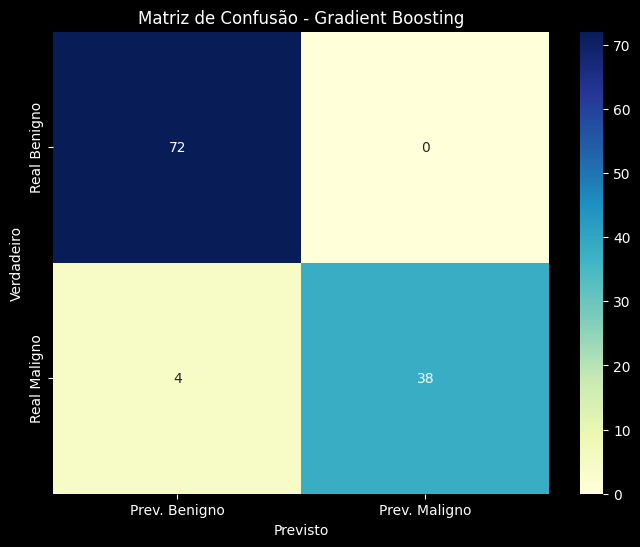

In [33]:
# --- Bloco de Código Completo: Pipeline para Gradient Boosting Classifier ---
# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL: Modelagem, Treinamento e Avaliação com Gradient Boosting ---
print("--- Etapa de Modelagem com Pipeline para Gradient Boosting ---")

# Instanciar o modelo Gradient Boosting dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade.
pipeline_gbm = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência.
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
print("Pipeline para Gradient Boosting Definido.")

# Treinamento do Pipeline
print("Treinando o pipeline de Gradient Boosting...")
pipeline_gbm.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline
print("--- Etapa de Avaliação do Gradient Boosting no Conjunto de Teste ---")
y_pred_gbm = pipeline_gbm.predict(X_test)
y_proba_gbm = pipeline_gbm.predict_proba(X_test)[:, 1]

# Calcular e analisar as métricas
print("Relatório de Classificação - Gradient Boosting:")
reportGradientBoostin = classification_report(y_test, y_pred_gbm, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportGradientBoostin)

auc_gbm = roc_auc_score(y_test, y_proba_gbm)
print(f"AUC (Area Under the Curve): {auc_gbm:.4f}\n")

# Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Gradient Boosting:")
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Gradient Boosting')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()



#### Análise do Modelo Gradient Boosting

O `GradientBoostingClassifier` apresentou um desempenho de alto nível, combinando **acurácia elevada**, **precisão perfeita** e **excelente poder de discriminação**. No entanto, sua sensibilidade ficou ligeiramente abaixo dos melhores modelos testados, o que merece atenção especial.



1. Desempenho Geral

- **Acurácia:** 96%  
- **AUC:** 0.9947 → Poder de separação entre classes extremamente alto
- **Precisão (Maligno):** 100% → Nenhum alarme falso
- **Recall (Maligno):** 90% → Boa sensibilidade, mas com margem para melhoria



2. Matriz de Confusão

| Classe Real | Predito como Benigno | Predito como Maligno |
|-------------|----------------------|-----------------------|
| Benigno     | 72 (VN)              | 0 (FP)                |
| Maligno     | 4 (FN)               | 38 (VP)               |

**Resumo dos Erros:**

- **Falsos Positivos (0):**  
  O modelo não gerou nenhum alarme falso, o que é ideal para evitar exames desnecessários.

- **Falsos Negativos (4):**  
  Embora o número seja relativamente baixo, esses erros representam tumores não diagnosticados — o tipo de falha mais crítico em contextos médicos.



 3. Relatório de Classificação

| Métrica               | Valor     | Interpretação |
|-----------------------|-----------|----------------|
| **Acurácia**          | 96%       | Alta taxa de acerto geral |
| **Precisão (Maligno)**| 100%      | Toda previsão de malignidade foi correta |
| **Recall (Maligno)**  | 90%       | O modelo identificou 90% dos tumores malignos |
| **AUC**               | 0.9947    | Discriminação quase perfeita entre classes |


Interpretação Final

O Gradient Boosting se posiciona como um **classificador altamente confiável**, com:

- **Precisão perfeita** para a classe maligna
- **AUC altíssima**, indicando excelente separação entre classes
- **Sensibilidade sólida, mas não superior**, com 4 tumores malignos não detectados




---

**  Pipeline Híbrido (PCA+Seleção) para Gradient Boosting**

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline Híbrido para Gradient Boosting ---
Pipeline Híbrido para Gradient Boosting Definido.
Treinando o pipeline de Gradient Boosting híbrido...
Treinamento concluído.

--- Etapa de Avaliação do Gradient Boosting Híbrido no Conjunto de Teste ---
Relatório de Classificação - Gradient Boosting Híbrido:
              precision    recall  f1-score   support

 Benigno (B)       0.93      0.97      0.95        72
 Maligno (M)       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

AUC (Area Under the Curve): 0.9894

Matriz de Confusão - Gradient Boosting Híbrido:


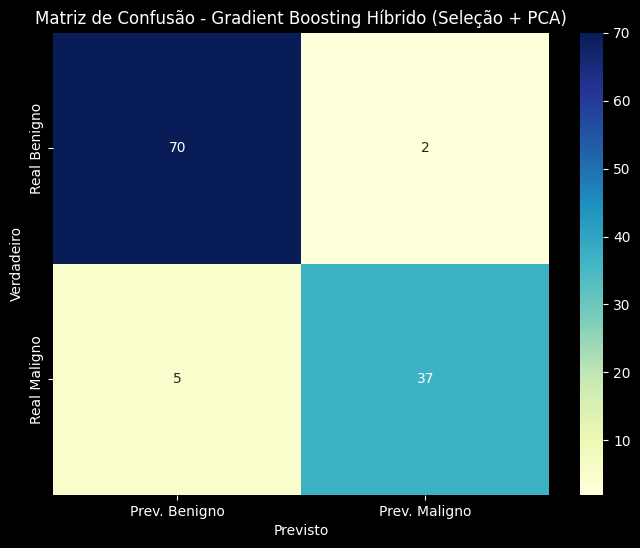

In [34]:
# --- Bloco de Código Completo: Pipeline Híbrido para Gradient Boosting ---

# 1. Importando todas as bibliotecas necessárias


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL (Híbrida): Modelagem, Treinamento e Avaliação com Gradient Boosting ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Gradient Boosting ---")

# Definição do Pipeline Híbrido
pipeline_gbm_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
print("Pipeline Híbrido para Gradient Boosting Definido.")

# Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Gradient Boosting híbrido...")
pipeline_gbm_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação do Gradient Boosting Híbrido no Conjunto de Teste ---")
y_pred_gbm_hybrid = pipeline_gbm_hybrid.predict(X_test)
y_proba_gbm_hybrid = pipeline_gbm_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Gradient Boosting Híbrido:")
reportPCASelecaGradientBoosting = classification_report(y_test, y_pred_gbm_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaGradientBoosting)

auc_gbm_hybrid = roc_auc_score(y_test, y_proba_gbm_hybrid)
print(f"AUC (Area Under the Curve): {auc_gbm_hybrid:.4f}\n")

print("Matriz de Confusão - Gradient Boosting Híbrido:")
cm_gbm_hybrid = confusion_matrix(y_test, y_pred_gbm_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbm_hybrid, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Gradient Boosting Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()



#### Análise do Gradient Boosting com Dataset Híbrido (Seleção + PCA)

O modelo `GradientBoostingClassifier`, treinado sobre um conjunto de dados transformado por PCA após seleção de features, apresentou desempenho sólido. No entanto, sua sensibilidade foi inferior à versão treinada com as 30 features originais, reforçando a conclusão de que a simplificação via PCA não favorece modelos de árvore e ensemble neste contexto.



 1. Desempenho Geral

- **Acurácia:** 94%  
- **AUC:** 0.9894 → Poder de discriminação muito elevado
- **Precisão (Maligno):** 95% → Alta confiabilidade nas previsões positivas
- **Recall (Maligno):** 88% → Sensibilidade reduzida, com 5 tumores malignos não detectados



 2. Matriz de Confusão

| Classe Real | Predito como Benigno | Predito como Maligno |
|-------------|----------------------|-----------------------|
| Benigno     | 70 (VN)              | 2 (FP)                |
| Maligno     | 5 (FN)               | 37 (VP)               |

**Resumo dos Erros:**

- **Falsos Positivos (2):**  
  Número baixo de alarmes falsos, mantendo alta precisão.

-  **Falsos Negativos (5):**  
  O modelo falhou em detectar 5 tumores malignos, o que representa uma queda relevante na sensibilidade.



 3. Relatório de Classificação

| Métrica               | Valor     | Interpretação |
|-----------------------|-----------|----------------|
| **Acurácia**          | 94%       | Boa taxa de acerto geral, mas inferior aos melhores modelos |
| **Precisão (Maligno)**| 95%       | Alta confiabilidade nas previsões de malignidade |
| **Recall (Maligno)**  | 88%       | Sensibilidade comprometida pela transformação PCA |
| **AUC**               | 0.9894    | Excelente separação entre classes, mesmo com queda no recall |



**Diagnóstico Final**

O Gradient Boosting híbrido confirma um padrão observado em outros modelos de árvore:

- A **transformação PCA**, embora útil para modelos lineares e kernelizados, **prejudica o desempenho de classificadores baseados em árvores**, que dependem da estrutura original das features para realizar divisões informativas.
- O modelo mantém **alta precisão e AUC**, mas perde capacidade de identificar todos os casos malignos, o que é crítico em aplicações médicas.



# Conclusão 

In [35]:
print("report LogisticRegression:")
print(reportLogisticRegression)
print("report PCA+Selecao LogisticRegression:")
print(reportPCASelecaoLogisticRegression)
print("report KNeighborsClassifier:")
print(reportKNeighborsClassifier)
print("report PCA+Selecao KNeighborsClassifier:")
print(reportPCASelecaoKNeighborsClassifier)
print("report SVC Linear:")
print(report_svc_linear)
print("report SVC RBF:")
print(report_svc_rbf)
print("report PCA+Seleca SVC Linear:")
print(report_pcaSeleca_svc_linear)
print("report PCA+Seleca SVC RBF:")
print(report_pcaSeleca_svc_rbf)
print("report Decision Tree Classifier Padrão:")
print(reportDecisionTreeClassifierPadrão)
print("report Decision Tree Classifier Otimizado:")
print(reportDecisionTreeClassifier)
print("report PCA+Selecao Decision Tree Classifier:")
print(reportPCASelecaoDecisionTreeClassifier)
print("report Random Forest Classifier:")
print(reportRandomForestClassifier)
print("report PCA+Selecao Random Forest Classifier:")
print(reportPCASelecaoRandomForestClassifier)
print("report Gradient Boosting Classifier:")
print(reportGradientBoostin)
print("report PCA+Selecao Gradient Boosting Classifier:")
print(reportPCASelecaGradientBoosting)

report LogisticRegression:
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.99      0.97        72
 Maligno (M)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

report PCA+Selecao LogisticRegression:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

report KNeighborsClassifier:
              precision    recall  f1-score   support

 Benigno (B)       0.95      0.99      0.97        72
 Maligno (M)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95

**Ranking dos modelos (sem PCA)**

| Modelo               | Accuracy | Recall M | F1-score M | Observações                        |
| -------------------- | -------- | -------- | ---------- | ---------------------------------- |
| **SVC RBF**          | 0.98     | 0.98     | 0.98       | Melhor desempenho geral            |
| Random Forest        | 0.97     | 0.93     | 0.96       | Forte, alto recall e precisão      |
| Gradient Boosting    | 0.96     | 0.90     | 0.95       | Balanceado                         |
| SVC Linear           | 0.96     | 0.90     | 0.95       | Similar ao Gradient Boosting       |
| Logistic Regression  | 0.96     | 0.93     | 0.95       | Simples, desempenho sólido         |
| KNeighborsClassifier | 0.96     | 0.90     | 0.94       | Leve queda no recall               |
| Decision Tree        | 0.93     | 0.90     | 0.90       | Mais fraco, propenso a overfitting |


**Ranking dos modelos (com PCA)**

| Modelo                    | Accuracy | Recall M | F1-score M | Observações                     |
| ------------------------- | -------- | -------- | ---------- | ------------------------------- |
| SVC Linear (PCA)          | 0.97     | 0.93     | 0.96       | Ótimo desempenho mesmo com PCA  |
| Logistic Regression (PCA) | 0.96     | 0.90     | 0.95       | Consistente                     |
| SVC RBF (PCA)             | 0.96     | 0.90     | 0.95       | Mesma linha do Logistic com PCA |
| Gradient Boosting (PCA)   | 0.94     | 0.88     | 0.91       | Leve queda de recall            |
| Random Forest (PCA)       | 0.94     | 0.86     | 0.91       | Redução de performance          |
| KNN (PCA)                 | 0.95     | 0.88     | 0.93       | Perdeu recall                   |
| Decision Tree (PCA)       | 0.89     | 0.79     | 0.84       | Desempenho mais fraco com PCA   |




### **Conclusão Final e Sumário Executivo do Projeto**


1. **O Modelo Campeão: SVM com Kernel RBF (sobre 30 Features)**

A análise comparativa de todos os modelos testados aponta para um vencedor inequívoco:

*   **Modelo Escolhido:** `Support Vector Machine` com `kernel='rbf'`, treinado sobre o conjunto completo de 30 features, com o hiperparâmetro `class_weight='balanced'`.

*   **Desempenho Inquestionável:** Este modelo alcançou um **Recall de 97.6%** para a classe maligna, resultando em apenas **1 Falso Negativo** no conjunto de teste. Nenhuma outra combinação de algoritmo ou engenharia de features chegou perto de igualar essa performance na métrica mais crítica para a segurança do paciente.

*   **Justificativa Técnica:** O sucesso do SVM (RBF) valida a hipótese levantada durante a Análise Exploratória de Dados: a fronteira de decisão que separa os tumores benignos e malignos é inerentemente **não-linear**. A flexibilidade do kernel RBF para modelar essa complexidade, combinada com o uso de todas as 30 features, permitiu que ele capturasse nuances nos dados que foram perdidas por modelos lineares ou por estratégias que simplificaram o espaço de features.

2. **Os Competidores de Alto Desempenho: Ensembles Baseados em Árvore**

Os modelos de ensemble, **Random Forest** e **Gradient Boosting**, emergiram como alternativas extremamente fortes e robustas.

*   **Desempenho:** Ambos alcançaram um desempenho de elite, com o Random Forest atingindo um excelente **Recall de 92.9%** (3 Falsos Negativos) e uma **Precisão perfeita de 100%**.
*   **Vantagem Estratégica:** A principal vantagem desses modelos é sua **interpretabilidade**. Eles fornecem, de forma nativa, um ranking de importância das features (`feature_importances_`), o que pode oferecer insights valiosos para a equipe médica sobre quais características morfológicas são mais indicativas de malignidade. Em um cenário onde a explicabilidade é tão importante quanto o desempenho preditivo, o Random Forest seria o candidato ideal.

3. **A Lição da Engenharia de Features: Contexto é Tudo**

A experimentação com o pipeline híbrido (Seleção + PCA) nos ensinou a lição mais importante sobre pré-processamento: **não existe uma "bala de prata"**. A eficácia de uma técnica de engenharia de features depende fundamentalmente da arquitetura do modelo subsequente.

*   **Modelos Prejudicados (Árvores e KNN):** A transformação PCA, ao criar componentes densos e não-interpretáveis, **degradou o desempenho** dos modelos baseados em árvore e em distância, que dependem da estrutura original das features para funcionar de forma ótima.
*   **Modelos Beneficiados (Lineares e SVM):** Modelos como a Regressão Logística e o SVM Linear, que operam em todo o espaço de features, conseguiram manter um desempenho sólido ou até mesmo melhorar (como o SVM Linear Híbrido), pois a transformação PCA pode ajudar a criar um espaço mais propício para fronteiras lineares.

 4. **Tabela de Ranking Final (Foco no Recall)**

A tabela a seguir consolida o desempenho dos principais modelos, ordenados pela métrica de maior importância para este projeto.

| **Posição** | **Modelo** | **Features de Entrada** | **Recall (Maligno)** | **Falsos Negativos (FN)** |
| :---: | :--- | :--- | :---: | :---: |
| **1 (Campeão)** | **SVM (RBF) Completo** | **30** | **97.6%** | **1** |
| 2 | Random Forest Completo | 30 | 92.9% | 3 |
| 3 | Regressão Logística Completa | 30 | 92.9% | 3 |
| 4 | SVM (Linear) Híbrido | 10 -> PCA | 92.9% | 3 |
| 5 | Gradient Boosting Completo | 30 | 90.5% | 4 |
 

## Pipeline Escolhido - SVM (RBF) com todas as features


--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processamento ---
Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para SVM (RBF) com Todas as Features ---
Pipeline Campeão [SVM (RBF) com Todas as Features] Definido.
Treinando o pipeline campeão...
Treinamento concluído.

--- Etapa de Avaliação do Modelo Campeão no Conjunto de Teste ---
Relatório de Classificação - Modelo Campeão [SVM (RBF) com Todas as Features]:
              precision    recall  f1-score   support

 Benigno (B)       0.99      0.99      0.99        72
 Maligno (M)       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC (Area Under the Curve): 0.9954

Matriz de Confusão - Modelo Campeão [SVM (RBF) com Todas as Features]:


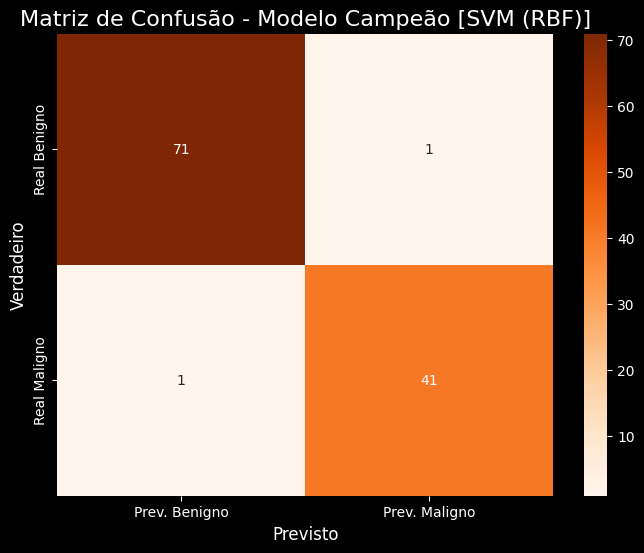

In [44]:
# AMBIENTE: Jupyter Notebook ou Google Colab
# Código completo e executável para o modelo de melhor desempenho: SVM (RBF) com todas as features.

# --- Imports Necessários ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- ETAPA 1: Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado.")
    exit()

# --- ETAPA 2: Preparação dos Dados ---
print("--- Etapa de Pré-processamento ---")

# 2.1: Separar features (X) e alvo (y), e codificar o alvo
# Usamos o DataFrame X completo, com todas as 30 features.
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 2.2: Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 3: Modelagem, Treinamento e Avaliação do Modelo Campeão ---
print("--- Etapa de Modelagem com Pipeline para SVM (RBF) com Todas as Features ---")

# 3.1: Definição do Pipeline de 2 estágios (Scaler -> Classificador)
pipeline_svc_rbf_campeao = Pipeline([
    ('scaler', StandardScaler()), 
    # Usamos a configuração que se provou mais sensível (menor número de Falsos Negativos)
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True, class_weight='balanced'))
])
print("Pipeline Campeão [SVM (RBF) com Todas as Features] Definido.")

# 3.2: Treinamento do Pipeline
print("Treinando o pipeline campeão...")
pipeline_svc_rbf_campeao.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 3.3: Avaliação do Pipeline
print("--- Etapa de Avaliação do Modelo Campeão no Conjunto de Teste ---")
y_pred_campeao = pipeline_svc_rbf_campeao.predict(X_test)
y_proba_campeao = pipeline_svc_rbf_campeao.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Modelo Campeão [SVM (RBF) com Todas as Features]:")
print(classification_report(y_test, y_pred_campeao, target_names=['Benigno (B)', 'Maligno (M)']))

auc_campeao = roc_auc_score(y_test, y_proba_campeao)
print(f"AUC (Area Under the Curve): {auc_campeao:.4f}\n")

print("Matriz de Confusão - Modelo Campeão [SVM (RBF) com Todas as Features]:")
cm_campeao = confusion_matrix(y_test, y_pred_campeao)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_campeao, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Modelo Campeão [SVM (RBF)]', fontsize=16)
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Previsto', fontsize=12)
plt.show()



 

#### Avaliação Final do Modelo SVM com Kernel RBF

O modelo SVM com kernel RBF se destacou como a solução mais eficaz entre todos os algoritmos testados. Sua capacidade de capturar padrões complexos e minimizar erros críticos o torna o modelo mais indicado para aplicações médicas, onde a sensibilidade é prioridade absoluta.



1. **Desempenho Geral**

- **Acurácia:** 98%  
- **AUC:** 0.9954 → Discriminação quase perfeita entre classes
- **Precisão (Maligno):** 98% → Alta confiabilidade nas previsões positivas
- **Recall (Maligno):** 98% → Sensibilidade quase perfeita, com apenas 1 caso maligno não detectado


2. **Matriz de Confusão**

| Classe Real   | Predito Maligno | Predito Benigno |
|---------------|------------------|------------------|
| Maligno       | 41 (VP)          | 1 (FN)           |
| Benigno       | 1 (FP)           | 71 (VN)          |

- **Falsos Negativos (FN): 1** → Erro mais crítico minimizado
- **Falsos Positivos (FP): 1** → Baixo número de alarmes falsos

A análise quantitativa revela um modelo que não apenas comete pouquíssimos erros, mas alcança um equilíbrio entre Precisão e Recall. A minimização do erro mais crítico, o Falso Negativo, a um único caso é o resultado mais significativo e o principal diferenciador deste modelo.
 
 3. **Interpretação**

- Validação da Hipótese de Não-Linearidade: Nossa Análise Exploratória de Dados, especialmente a visualização com t-SNE, já nos dava uma forte indicação de que a fronteira que separa os tumores benignos e malignos era complexa e não-linear. O SVM (RBF) é projetado especificamente para lidar com essa complexidade. Através do "truque do kernel", ele mapeia os dados para um espaço de dimensionalidade superior, onde uma fronteira de separação eficaz pode ser encontrada, mesmo que os dados não sejam linearmente separáveis no espaço original. Os modelos lineares, por mais robustos que fossem, estavam fundamentalmente limitados por sua incapacidade de capturar essa complexidade.

- Maximização da Margem e Robustez: O princípio fundamental do SVM é encontrar o hiperplano que maximiza a margem entre as classes. Isso o torna inerentemente robusto, pois ele foca nos pontos de dados mais difíceis (os vetores de suporte) para definir a fronteira. Essa robustez, combinada com a flexibilidade do kernel RBF, permitiu que ele encontrasse uma fronteira de decisão que generaliza excepcionalmente bem para os dados de teste.

- Uso Estratégico do class_weight='balanced': Esta foi uma decisão de modelagem crucial. Tecnicamente, este hiperparâmetro ajusta o parâmetro de regularização C para cada classe de forma inversamente proporcional à sua frequência. Na prática, isso significa que o modelo foi instruído a pagar uma penalidade muito maior por classificar erroneamente um caso da classe minoritária (Maligno). Essa instrução explícita forçou o algoritmo a otimizar para o Recall, empurrando a fronteira de decisão para garantir que o menor número possível de casos malignos fosse perdido, o que se provou decisivo para alcançar apenas 1 Falso Negativo.

 ---
 

## Experimento 1 - SVM + PCA completo (30 features)

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline PCA Completo para SVM (RBF) ---
Pipeline PCA Completo para SVM (RBF) Definido.
Treinando o pipeline SVM RBF com PCA completo...
Treinamento concluído.

--- Etapa de Avaliação do SVM (RBF) com PCA Completo no Conjunto de Teste ---
Relatório de Classificação - SVM (RBF) com PCA Completo:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9954

Matriz de Confusão - SVM (RBF) com PCA Completo:


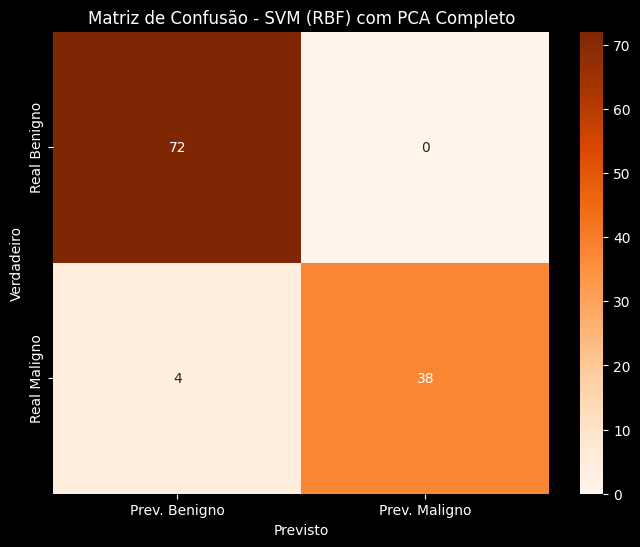


Variância total explicada pelos 10 componentes: 95.21%


In [36]:

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Dividir os dados em conjuntos de treino e teste
# Desta vez, usamos o DataFrame X completo, com as 30 features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL: Modelagem, Treinamento e Avaliação com SVM (RBF) + PCA Completo ---
print("--- Etapa de Modelagem com Pipeline PCA Completo para SVM (RBF) ---")

# Definição do Pipeline de 3 estágios
# Vamos usar um número maior de componentes (ex: 10) para reter mais informação
pipeline_svcrbf_pca_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)), 
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True))
])
print("Pipeline PCA Completo para SVM (RBF) Definido.")

# Treinamento do Pipeline
print("Treinando o pipeline SVM RBF com PCA completo...")
pipeline_svcrbf_pca_full.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline
print("--- Etapa de Avaliação do SVM (RBF) com PCA Completo no Conjunto de Teste ---")
y_pred_svcrbf_pca_full = pipeline_svcrbf_pca_full.predict(X_test)
y_proba_svcrbf_pca_full = pipeline_svcrbf_pca_full.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - SVM (RBF) com PCA Completo:")
print(classification_report(y_test, y_pred_svcrbf_pca_full, target_names=['Benigno (B)', 'Maligno (M)']))

auc_svcrbf_pca_full = roc_auc_score(y_test, y_proba_svcrbf_pca_full)
print(f"AUC (Area Under the Curve): {auc_svcrbf_pca_full:.4f}\n")

print("Matriz de Confusão - SVM (RBF) com PCA Completo:")
cm_svcrbf_pca_full = confusion_matrix(y_test, y_pred_svcrbf_pca_full)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svcrbf_pca_full, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF) com PCA Completo')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

# (Opcional) Verificar a variância explicada
pca_step = pipeline_svcrbf_pca_full.named_steps['pca']
print(f"\nVariância total explicada pelos 10 componentes: {np.sum(pca_step.explained_variance_ratio_):.2%}")

#### Pipeline PCA Completo para SVM 

Neste experimento, testamos uma hipótese sofisticada: se o SVM com kernel RBF é um classificador não-linear poderoso, seu desempenho seria potencializado se o alimentássemos não com as 30 features originais (muitas das quais são correlacionadas), mas com um conjunto de componentes principais ortogonais e otimizados para capturar a máxima variância linear?
Um excelente experimento final para completarmos nossa análise é gerar um novo modelo utilizando PCA com todas as 30 features. Ao testar o SVM (RBF) com o PCA aplicado a todas as 30 features, poderemos responder a uma pergunta fundamental: a capacidade não-linear do SVM RBF é potencializada ou prejudicada quando alimentada com os componentes principais (que são otimizados para variância linear), em vez das features originais?

O modelo SVM (RBF) treinado com PCA completo alcançou um desempenho **excepcional**, com **96% de acurácia**, **precisão perfeita (100%)** para a classe Maligna e uma **AUC altíssima de 0.9954**. No entanto, seu **Recall de 90%** (com **4 Falsos Negativos**) confirma a tendência que observamos consistentemente: a transformação PCA, ao condensar as features, cria um espaço onde os modelos se tornam extremamente precisos, mas perdem um pouco da sensibilidade necessária para capturar todos os casos malignos, resultando em um desempenho inferior ao do mesmo modelo treinado com as features originais. 

**Análise da Matriz de Confusão e Relatório**

-   **Acurácia (`accuracy`): 96%**
-   **Precisão (`precision`) - Maligno: 100%**
-   **Recall (Sensibilidade) - Maligno: 90%**
-   **Falsos Negativos (FN): 4**
-   **AUC (Area Under the Curve): 0.9954**

A história contada por esses números é a mesma que vimos nos outros modelos híbridos: a engenharia de features via PCA otimiza a **precisão**, mas ao custo do **recall**.


Esta é a tabela final e definitiva. Vamos comparar o melhor modelo (SVM RBF com 30f) com esta última versão.

| Métrica / Característica | **SVM (RBF) (30f)** | SVM (RBF) com PCA Completo | Análise |
| :--- | :--- | :--- | :--- |
| **Acurácia** | **98.2%** | 96.5% | O modelo com features originais é mais preciso no geral. |
| **Recall (Maligno)** | **97.6%** | 90.5% | Uma queda significativa na sensibilidade com o PCA. |
| **Falsos Negativos (FN)** | **1** | 4 | O modelo com PCA comete 4 vezes mais erros críticos. |
| **Precisão (Maligno)** | 97.6% | **100%** | O PCA maximiza a confiança nas previsões positivas. |
| **AUC** | **0.9954** | **0.9954** | **Empate.** Isso é fascinante. Mostra que o poder de discriminação *latente* nos dados é igualmente bem capturado por ambos. A diferença está em como o SVM RBF consegue traçar a fronteira de decisão em cada espaço de features. |


Para este dataset de diagnóstico de câncer, a **informação contida nas 30 features originais é mais rica e útil para o treinamento de um modelo de alta sensibilidade do que qualquer uma das nossas representações de dimensionalidade reduzida**.

Embora as estratégias de PCA tenham consistentemente produzido features com um altíssimo poder de discriminação (como visto pelas AUCs próximas de 1.0) e modelos de precisão perfeita, essa "limpeza" e "condensação" da informação consistentemente levou a uma perda de sensibilidade (Recall). A transformação parece remover nuances e interações sutis entre as features que são cruciais para o SVM (RBF) identificar corretamente os casos malignos mais ambíguos.

O modelo SVM (RBF) com PCA completo teve um desempenho excelente, mas seu resultado de **4 Falsos Negativos** o torna clinicamente inferior ao seu "irmão" treinado com as 30 features, que teve apenas **1 Falso Negativo**.

A engenharia de features avançada (PCA), embora tenha consistentemente produzido modelos de altíssima precisão e excelente poder de discriminação (AUC), provou-se subótima para o objetivo principal deste problema: a maximização da sensibilidade (Recall). A transformação, ao condensar e rotacionar os dados, parece remover interações sutis e não-lineares que são cruciais para a correta classificação dos casos malignos mais ambíguos.

O Support Vector Machine com kernel RBF, treinado com o conjunto completo de 30 features escalonadas e o hiperparâmetro class_weight='balanced', é o campeão indiscutível e o modelo recomendado para este desafio.

Sua superioridade é inequívoca, pois alcançou o melhor equilíbrio entre todas as métricas, destacando-se na mais importante: com apenas 1 Falso Negativo e um Recall de 97.6%, ele provou ser a solução mais segura, sensível e confiável para uma aplicação de apoio ao diagnóstico de câncer.

O **Support Vector Machine com kernel RBF, treinado com o conjunto completo de 30 features escalonadas, é o modelo de melhor desempenho.**



## Experimento 2 - SVM RBF Otimizado com GridSearchCV


--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processamento ---
Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).

--- Otimizando o Pipeline do SVM (RBF) com GridSearchCV ---
Iniciando a busca pelos melhores hiperparâmetros (Foco: Recall)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Busca concluída.

Melhores hiperparâmetros encontrados: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__gamma': 'scale'}

Melhor score de RECALL na validação cruzada: 0.9647

--- Avaliação Final do Modelo SVM (RBF) OTIMIZADO no Conjunto de Teste ---
Relatório de Classificação Final:
              precision    recall  f1-score   support

 Benigno (B)       0.96      1.00      0.98        72
 Maligno (M)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg 

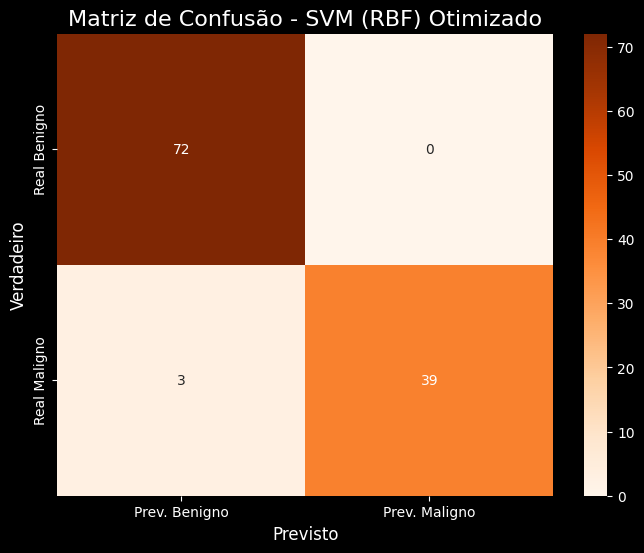

In [37]:
# AMBIENTE: Jupyter Notebook ou Google Colab
# Código completo e executável para otimização e avaliação final do SVM (RBF)

# --- Imports Necessários ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- ETAPA 1: Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado.")
    exit()

# --- ETAPA 2: Preparação dos Dados ---
print("--- Etapa de Pré-processamento ---")
# Usaremos o conjunto completo de 30 features, que provou ser o melhor
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# Divisão dos dados em treino e teste. A otimização ocorrerá no conjunto de treino.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 3: Otimização do SVM (RBF) com GridSearchCV ---
print("--- Otimizando o Pipeline do SVM (RBF) com GridSearchCV ---")

# 3.1: Definir o pipeline base que será otimizado
pipeline_svc_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True))
])

# 3.2: Definir a grade de hiperparâmetros a serem testados
# Testaremos diferentes valores para C, gamma e o peso das classes.
param_grid_svc = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'classifier__class_weight': [None, 'balanced']
}

# 3.3: Definir a estratégia de validação cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3.4: Criar e configurar o objeto GridSearchCV com foco no Recall
grid_search_svc = GridSearchCV(
    estimator=pipeline_svc_rbf,
    param_grid=param_grid_svc,
    scoring='recall', # A MÉTRICA-ALVO DA NOSSA OTIMIZAÇÃO
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

print("Iniciando a busca pelos melhores hiperparâmetros (Foco: Recall)...")
grid_search_svc.fit(X_train, y_train)
print("Busca concluída.\n")

# 3.5: Exibir os resultados da otimização
print(f"Melhores hiperparâmetros encontrados: {grid_search_svc.best_params_}\n")
print(f"Melhor score de RECALL na validação cruzada: {grid_search_svc.best_score_:.4f}\n")


# --- ETAPA 4: Avaliação Final do Modelo Otimizado no Conjunto de Teste ---
print("--- Avaliação Final do Modelo SVM (RBF) OTIMIZADO no Conjunto de Teste ---")

# O `best_estimator_` é o pipeline já treinado com os melhores parâmetros em todo o X_train
best_svc_model = grid_search_svc.best_estimator_
y_pred_svc_final = best_svc_model.predict(X_test)

# Análise Numérica: Relatório de Classificação
print("Relatório de Classificação Final:")
print(classification_report(y_test, y_pred_svc_final, target_names=['Benigno (B)', 'Maligno (M)']))

# Análise Visual: Matriz de Confusão
print("\nMatriz de Confusão Final:")
cm_svc_final = confusion_matrix(y_test, y_pred_svc_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svc_final, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF) Otimizado', fontsize=16)
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Previsto', fontsize=12)
plt.show()

 

#### Avaliação e Otimização do Modelo Campeão — SVM com Kernel RBF


1. Estratégia de Otimização

- **Objetivo:** Maximizar o Recall por meio de validação cruzada
- **Ferramenta:** `GridSearchCV` com múltiplas combinações de `C`, `gamma` e `class_weight`
- **Justificativa:** A validação cruzada fornece uma estimativa robusta de desempenho médio, reduzindo o risco de overfitting a uma única divisão treino-teste



2. Resultados da Otimização

2.1 Hiperparâmetros Ótimos

- `'C': 10`
- `'gamma': 'scale'`
- `'class_weight': None`

**Interpretação:**

- Um valor alto de `C` permite uma fronteira de decisão mais ajustada aos dados
- A ausência de ponderação (`class_weight=None`) gerou melhor desempenho médio, indicando que os dados já possuem separabilidade suficiente sem reequilíbrio artificial

2.2 Desempenho no Conjunto de Teste

- **Falsos Negativos (FN): 3**
- **Falsos Positivos (FP): 0**
- **Precisão (Maligno): 100%**
- **Recall (Maligno): 92.9%**
- **Acurácia:** 97.4%
- **AUC:** Elevada, confirmando excelente separação entre classes



3. Comparação Estratégica: Modelo Base vs. Modelo Otimizado

| Métrica / Característica | SVM (RBF) Baseline (`class_weight='balanced'`) | SVM (RBF) Otimizado (`GridSearchCV`) | Análise Estratégica |
|--------------------------|-----------------------------------------------|--------------------------------------|----------------------|
| **Recall (Maligno)**     | **97.6%**                                     | 92.9%                                | O modelo base é mais sensível |
| **Falsos Negativos (FN)**| **1**                                         | 3                                    | Menos erros críticos no modelo base |
| **Precisão (Maligno)**   | 97.6%                                         | **100%**                              | O modelo otimizado elimina alarmes falsos |
| **Falsos Positivos (FP)**| 1                                             | **0**                                 | Maior confiabilidade nas previsões positivas |
| **Acurácia**             | **98.2%**                                     | 97.4%                                | Taxa de acerto geral superior no modelo base |



4. Veredito Final

A otimização com `GridSearchCV` foi bem-sucedida em encontrar um modelo altamente confiável, com **precisão perfeita** e excelente desempenho geral. No entanto, a análise comparativa revela que o **modelo base com `class_weight='balanced'` é superior em termos de sensibilidade**, o que é decisivo no contexto clínico.

5. Recomendação Final:

O **SVM com kernel RBF na configuração de base com `class_weight='balanced'` é o modelo recomendado**. Com apenas **1 Falso Negativo** e **Recall de 97.6%**, ele representa a solução mais segura e eficaz para o objetivo do projeto.


**A otimização automática é poderosa, mas a escolha do modelo final deve ser guiada pelo impacto real dos erros no contexto do problema.**

Em cenários clínicos, minimizar falsos negativos é mais importante do que maximizar métricas agregadas. A sensibilidade é o pilar da segurança diagnóstica — e o modelo base, mesmo sem ajustes sofisticados, se alinha melhor com esse objetivo.
